<a href="https://colab.research.google.com/github/GUNAPILLCO/neural_profit/blob/main/2_feature_engineering/2_3_correlation_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2_3_correlation_features

## Resumen


Esta notebook se centra en el **cálculo y análisis de indicadores técnicos intradía** aplicados al índice  **Micro E-mini Nasdaq 100 (MNQ)**, con el fin de construir features que sirvan como insumo para modelos predictivos.

---

## 🔹 Pasos principales

0. **Configuración de entorno**
   - Clonado del repositorio y carga de librerías.
   - Lectura del dataset `mnq_intraday_data` en formato Parquet.

1. **Definición de la variable objetivo**
   - Se construye el **retorno futuro a 30 minutos** (`target_return_30`).
   - Se selecciona este horizonte porque mostró mejor correlación (IC medio) con indicadores técnicos.

2. **Cálculo de indicadores técnicos**
   Los indicadores se aplican sobre series intradía (OHLCV) para capturar patrones de corto plazo:
   - **RSI (Relative Strength Index)**: mide sobrecompra/sobreventa en ventanas 3, 5, 7 y 14.
   - **Momentum**: mide aceleración o presión del precio en ventanas 3, 5 y 10.
   - **Relación de volumen**: compara volumen actual vs. su media móvil (15, 20, 30).
   - **MACD diferencial**: diferencia entre línea MACD y su señal, para detectar posibles cambios de tendencia.

3. **Dataset enriquecido**
   - Se añade el target y los indicadores calculados como nuevas columnas.
   - El resultado es un dataset listo para análisis de hipótesis y evaluación de factores.

---

✅ **Resultado:**  
Un dataset intradía del MNQ con el target de 30 minutos y un conjunto de indicadores técnicos relevantes (RSI, Momentum, Volumen, MACD), listos para ser evaluados en etapas posteriores de **feature engineering y modelado**.

## 0. Configuración del Entorno


### 0.1. Clonado de repositorio / Acceso a Drive

In [1]:
#Clonamos el repo
#LINK DE REPOSITORIO: https://github.com/GUNAPILLCO/neural_profit
!git clone https://github.com/GUNAPILLCO/neural_profit.git

Cloning into 'neural_profit'...
remote: Enumerating objects: 482, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 482 (delta 61), reused 33 (delta 21), pack-reused 380 (from 2)
Receiving objects: 100% (482/482), 249.17 MiB | 13.28 MiB/s, done.
Resolving deltas: 100% (276/276), done.
Updating files: 100% (59/59), done.


In [2]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = "/content/drive/MyDrive/neural_profit"

Mounted at /content/drive


### 0.2. Instalación de librerías


In [5]:
!{sys.executable} -m pip install -q ta
print("Librería instalada: technical-analysis")

  Preparing metadata (setup.py) ... done
Librería instalada: technical-analysis


### 0.3. Importación de librerías


In [6]:
import sys
import re
#Instalación de librería pandas_market_calendars
#!{sys.executable} -m pip install -q pandas_market_calendars
#print("Librería instalada: pandas_market_calendars")


from functools import reduce
# Utilidades generales
from datetime import datetime, timedelta
import os
import glob
import requests
import warnings
warnings.filterwarnings('ignore')

# Manejo y procesamiento de datos
import ta
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
# Calendario de mercados
#import pandas_market_calendars as mcal

from ta.momentum import StochasticOscillator, ROCIndicator
from ta.volatility import BollingerBands, AverageTrueRange

from scipy.stats import spearmanr


### 0.4. Carga de dataset MNQ




In [7]:
def load_data(data: str):

    data_path = f'{drive_path}/2_feature_engineering/mnq_{data}.parquet'

    # Leer el archivo Parquet y cargarlo en un DataFrame
    df = pd.read_parquet(data_path)

    # Asegurar que el índice esté en formato datetime
    df.index = pd.to_datetime(df.index)

    # Crear una nueva columna 'date' con la fecha extraída del índice
    df['date'] = df.index.date

    # Reordenar columnas: 'date', 'time_str', y luego el resto
    cols = ['date'] + [col for col in df.columns if col not in ['date']]

    df = df[cols]

    return df

In [8]:
mnq_technical_indicators = load_data('technical_indicators')

In [13]:
mnq_alpha_factors = load_data('alpha_factors')

In [15]:
mnq_technical_indicators.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'target_return_5',
       'target_return_15', 'target_return_30', 'target_return_60',
       'target_return_90', 'rsi_14', 'rsi_7', 'momentum_10', 'momentum_5',
       'macd', 'price_ema20', 'price_ema30', 'stoch_k_20', 'stoch_k_30',
       'bb_20', 'bb_30', 'bb_60', 'atr_norm', 'roc_20', 'roc_30', 'roc_60'],
      dtype='object')

In [14]:
mnq_alpha_factors.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'target_return_30',
       'target_return_60', 'target_return_90', 'rev_mom_z_30', 'rev_mom_z_45',
       'rev_mom_z_60', 'rev_mom_z_90', 'rev_score_30', 'rev_score_45',
       'rev_score_60', 'rev_score_90', 'rev_mom_vol_z_45', 'rev_mom_vol_z_60',
       'rev_mom_vol_z_90', 'ire_60', 'ire_90'],
      dtype='object')

### 0.5. Info de dataset MNQ


In [17]:
def info_dataset(df):
  print("Información del dataset:\n")

  # Contar valores únicos en la columna 'date'
  num_dias = df['date'].nunique()
  print(f"\tCantidad de días: {num_dias}")

  # Filtrar valores válidos
  validos_por_dia = df.dropna(subset=['close']).groupby('date').size()

  # Calcular el promedio
  promedio_por_fecha = validos_por_dia.mean()
  print(f"\tRegistros por día: {int(promedio_por_fecha)}")

  primer_hora = df.index[0].strftime('%H:%M')
  ultima_hora = df.index[-1].strftime('%H:%M')
  zona_horaria = df.index[0].tzinfo


  print(f"\tHora diaria de inicio {primer_hora}")
  print(f"\tHora diaria de final {ultima_hora}")
  print(f"\tZona horaria: {zona_horaria}")

In [18]:
info_dataset(mnq_alpha_factors)

Información del dataset:

	Cantidad de días: 1311
	Registros por día: 481
	Hora diaria de inicio 08:00
	Hora diaria de final 16:00
	Zona horaria: America/New_York


In [19]:
info_dataset(mnq_technical_indicators)

Información del dataset:

	Cantidad de días: 1311
	Registros por día: 481
	Hora diaria de inicio 08:00
	Hora diaria de final 16:00
	Zona horaria: America/New_York


## 1. Relación entre indicadores técnicos y el target de retorno

Los indicadores técnicos se construyen a partir de la serie de precios, y en particular sobre la variable de cierre (close). Son transformaciones matemáticas que capturan patrones como tendencias, momentum, volatilidad o sobrecompra/sobreventa.

Sin embargo, nuestra variable objetivo (target) no es el precio de cierre en sí, sino el retorno acumulado a futuro, calculado en distintos horizontes temporales (5, 15, 30, 60 minutos).

Esto significa que, aunque los indicadores se calculen directamente sobre el precio de cierre, lo que realmente buscamos evaluar es su capacidad para anticipar la dirección y magnitud de los retornos futuros.

En consecuencia, el análisis no se centra en explicar la evolución del precio minuto a minuto, sino en medir el poder predictivo de cada indicador técnico respecto a los targets de retorno.

In [ ]:
def add_targets (df):
  df['target_return_5'] = df.groupby('date')['close'].transform(lambda x: np.log(x.shift(-5)) - np.log(x))
  df['target_return_15'] = df.groupby('date')['close'].transform(lambda x: np.log(x.shift(-15)) - np.log(x))
  df['target_return_30'] = df.groupby('date')['close'].transform(lambda x: np.log(x.shift(-30)) - np.log(x))
  df['target_return_60'] = df.groupby('date')['close'].transform(lambda x: np.log(x.shift(-60)) - np.log(x))
  df['target_return_90'] = df.groupby('date')['close'].transform(lambda x: np.log(x.shift(-90)) - np.log(x))

  return df

In [ ]:
mnq_intraday = add_targets(mnq_intraday)

## 2. Indicadores Técnicos

Los indicadores técnicos calculados en cada jornada tienen como objetivo capturar dinámicas intradía relevantes del precio y el volumen, tales como momentum, sobrecompra/sobreventa, presión institucional o posibles reversiones. Cada uno aporta información complementaria sobre el comportamiento del mercado a corto plazo. En particular:

### 2.1. **RSI (Relative Strength Index)**

Mide la fuerza relativa del precio en los últimos períodos (3, 5, 7, 14), oscilando entre 0 y 100.

  - Valores altos indican posibles condiciones de sobrecompra, mientras que valores bajos sugieren sobreventa.
  
  - Calculado sobre los precios de cierre intradía, el RSI es útil para identificar puntos de reversión potenciales en el corto plazo.

In [ ]:
def calcular_rsi(df=mnq_intraday, target='close' ):
  rsi_columns = ['rsi_14', 'rsi_7', 'rsi_5', 'rsi_3']

  def aplicar_por_dia (grupo):
        grupo = grupo.copy()
        grupo['rsi_14'] = ta.momentum.RSIIndicator(grupo[target], window=14).rsi()
        grupo['rsi_7'] = ta.momentum.RSIIndicator(grupo[target], window=7).rsi()
        grupo['rsi_5'] = ta.momentum.RSIIndicator(grupo[target], window=5).rsi()
        grupo['rsi_3'] = ta.momentum.RSIIndicator(grupo[target], window=3).rsi()
        return grupo

  df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)
  return df, rsi_columns

### 2.2. **Momentum**

Mide la aceleración reciente del precio mediante la variación porcentual entre el precio actual y el de hace N minutos.

  - Un valor positivo indica una subida reciente, lo que podría sugerir una continuación alcista.

  - Un valor negativo señala presión bajista reciente, potencialmente anticipando una continuación a la baja.

In [ ]:
def calcular_momentum(df=mnq_intraday, target='close' ):
  momentum_columns = ['momentum_10', 'momentum_5','momentum_3']

  def aplicar_por_dia (grupo):
        grupo = grupo.copy()
        grupo['momentum_10'] = grupo[target].pct_change(10)
        grupo['momentum_5'] = grupo[target].pct_change(5)
        grupo['momentum_3'] = grupo[target].pct_change(3)
        return grupo

  df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)
  return df, momentum_columns

### 2.3. **Relación de volumen actual vs. su promedio reciente**

Compara el volumen actual con su media móvil en distintas ventanas de tiempo: 15, 20 y 30 minutos.

  - Un valor mayor a 1 indica un volumen superior al promedio de la ventana correspondiente, lo que puede reflejar interés creciente o actividad institucional.

  - Un valor menor a 1 sugiere baja actividad o consolidación del precio.

Esta métrica permite detectar aumentos de volumen ("spikes") sin depender del volumen en crudo, y las diferentes ventanas permiten capturar variaciones en la dinámica de corto plazo con distinta sensibilidad.


In [ ]:
def calcular_volumen_ratio(df=mnq_intraday, target='close'):
  volume_ratio_columns = ['volume_ratio_15', 'volume_ratio_20', 'volume_ratio_30', 'volume_ratio_60', 'volume_ratio_90']

  def aplicar_por_dia (grupo):
        grupo = grupo.copy()
        grupo['volume_ratio_15'] = grupo['volume'] / grupo['volume'].rolling(15).mean()
        grupo['volume_ratio_20'] = grupo['volume'] / grupo['volume'].rolling(20).mean()
        grupo['volume_ratio_30'] = grupo['volume'] / grupo['volume'].rolling(30).mean()
        grupo['volume_ratio_60'] = grupo['volume'] / grupo['volume'].rolling(60).mean()
        grupo['volume_ratio_90'] = grupo['volume'] / grupo['volume'].rolling(90).mean()
        return grupo

  df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)

  return df, volume_ratio_columns

### 2.4. **MACD diferencial (señal de cruce)**

Representa la diferencia entre la línea MACD y su línea de señal (una media exponencial de sí misma).

  - Un valor positivo y creciente indica momentum alcista.

  - Un valor negativo sugiere presión bajista.
  
Es ampliamente utilizado para detectar giros de tendencia y cambios en la dinámica del mercado.


In [ ]:
def calcular_macd(df=mnq_intraday, target='close'):
    macd_columns = ['macd']

    def aplicar_por_dia(grupo):
        grupo = grupo.copy()
        grupo['macd'] = ta.trend.MACD(grupo[target]).macd_diff()
        return grupo

    df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)

    return df, macd_columns

### 2.5. **Distancia del precio actual a su EMA (15, 20 y 30 minutos)**

Mide el desvío porcentual del precio respecto a su media exponencial en diferentes ventanas, y actúa como indicador de sobreextensión o retorno a la media.

  - Si el precio está muy por encima de la EMA, puede anticipar una reversión bajista o una posible aceleración alcista.

  - Si está por debajo, podría indicar agotamiento o presión vendedora.<br>

Esta métrica se expresa como un porcentaje relativo, lo que facilita la comparación entre distintas ventanas temporales y condiciones de mercado.

Usar varias ventanas (15, 20 y 30 minutos) permite capturar diferentes horizontes de reacción del precio frente a su media móvil.


In [ ]:
def calcular_ema(df=mnq_intraday, target='close'):
    ema_columns = ['price_ema15', 'price_ema20', 'price_ema30',  'price_ema60']

    def aplicar_por_dia(grupo):
        grupo = grupo.copy()
        grupo['price_ema15'] = grupo[target] / grupo[target].ewm(span=15).mean() - 1
        grupo['price_ema20'] = grupo[target] / grupo[target].ewm(span=20).mean() - 1
        grupo['price_ema30'] = grupo[target] / grupo[target].ewm(span=30).mean() - 1
        grupo['price_ema60'] = grupo[target] / grupo[target].ewm(span=60).mean() - 1
        return grupo

    df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)

    return df, ema_columns

### 2.6. **%K Estocástico**

Mide la posición relativa del precio actual dentro del rango alto-bajo de los últimos n periodos (generalmente 14).

  - Se utiliza para identificar condiciones extremas de sobrecompra o sobreventa.

  - Un valor cercano a 100 indica que el precio está cerca del máximo reciente (potencial sobrecompra), mientras que un valor cercano a 0 indica proximidad al mínimo reciente (posible sobreventa).

Es útil para detectar momentos en los que el precio puede estar excesivamente extendido y susceptible a una reversión.


In [ ]:
def calcular_stochastic(df=mnq_intraday, target='close'):
    stoch_columns = ['stoch_k_14', 'stoch_k_20', 'stoch_k_30']

    def aplicar_por_dia(grupo):
        grupo = grupo.copy()

        stoch_14 = StochasticOscillator(
            high=grupo['high'], low=grupo['low'], close=grupo[target], window=14, smooth_window=3
        )
        grupo['stoch_k_14'] = stoch_14.stoch()

        stoch_20 = StochasticOscillator(
            high=grupo['high'], low=grupo['low'], close=grupo[target], window=20, smooth_window=3
        )
        grupo['stoch_k_20'] = stoch_20.stoch()

        stoch_30 = StochasticOscillator(
            high=grupo['high'], low=grupo['low'], close=grupo[target], window=30, smooth_window=3
        )
        grupo['stoch_k_30'] = stoch_30.stoch()

        return grupo

    df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)

    return df, stoch_columns


### 2.7.**%B de Bollinger (Bollinger Band Percent)**

Indica la posición del precio actual en relación con las bandas de Bollinger, que están construidas alrededor de una media móvil usando desviaciones estándar.

  - Un valor de %B > 1 sugiere que el precio está por encima de la banda superior, lo que podría implicar exceso de optimismo o momentum fuerte.

  - Un valor < 0 indica que está por debajo de la banda inferior, posible señal de pánico o sobreventa extrema.

Este indicador es eficaz para identificar zonas de congestión, breakout o reversiones basadas en la volatilidad reciente.


In [ ]:
from ta.volatility import BollingerBands

def calcular_bollinger(df=mnq_intraday, target='close'):
    '''bollinger_columns = [
        'bb_percent_15_15', 'bb_percent_20_15', 'bb_percent_30_15',
        'bb_percent_15_20', 'bb_percent_20_20', 'bb_percent_30_20',
        'bb_percent_15_25', 'bb_percent_20_25', 'bb_percent_30_25',
    ]'''

    bollinger_columns = [
        'bb_15_15', 'bb_20_15', 'bb_30_15', 'bb_60_15',
        'bb_15_20', 'bb_20_20', 'bb_30_20', 'bb_60_20',
        'bb_15_25', 'bb_20_25', 'bb_30_25', 'bb_60_25',
    ]

    def aplicar_por_dia(grupo):
        grupo = grupo.copy()

        # std: 1.5
        grupo['bb_15_15'] = BollingerBands(grupo[target], window=15, window_dev=1.5).bollinger_pband()
        grupo['bb_20_15'] = BollingerBands(grupo[target], window=20, window_dev=1.5).bollinger_pband()
        grupo['bb_30_15'] = BollingerBands(grupo[target], window=30, window_dev=1.5).bollinger_pband()
        grupo['bb_60_15'] = BollingerBands(grupo[target], window=60, window_dev=1.5).bollinger_pband()

        # std: 2
        grupo['bb_15_20'] = BollingerBands(grupo[target], window=15, window_dev=2).bollinger_pband()
        grupo['bb_20_20'] = BollingerBands(grupo[target], window=20, window_dev=2).bollinger_pband()
        grupo['bb_30_20'] = BollingerBands(grupo[target], window=30, window_dev=2).bollinger_pband()
        grupo['bb_60_20'] = BollingerBands(grupo[target], window=60, window_dev=2).bollinger_pband()

        # std: 2.5
        grupo['bb_15_25'] = BollingerBands(grupo[target], window=15, window_dev=2.5).bollinger_pband()
        grupo['bb_20_25'] = BollingerBands(grupo[target], window=20, window_dev=2.5).bollinger_pband()
        grupo['bb_30_25'] = BollingerBands(grupo[target], window=30, window_dev=2.5).bollinger_pband()
        grupo['bb_60_25'] = BollingerBands(grupo[target], window=60, window_dev=2.5).bollinger_pband()



        return grupo

    df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)

    return df, bollinger_columns


In [ ]:
def calcular_bollinger_resume(df=mnq_intraday, target='close'):

    bollinger_columns = [
        'bb_15', 'bb_20', 'bb_30', 'bb_60',
    ]

    def aplicar_por_dia(grupo):
        grupo = grupo.copy()

        # std: 2
        grupo['bb_15'] = BollingerBands(grupo[target], window=15, window_dev=2).bollinger_pband()
        grupo['bb_20'] = BollingerBands(grupo[target], window=20, window_dev=2).bollinger_pband()
        grupo['bb_30'] = BollingerBands(grupo[target], window=30, window_dev=2).bollinger_pband()
        grupo['bb_60'] = BollingerBands(grupo[target], window=60, window_dev=2).bollinger_pband()
        return grupo

    df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)

    return df, bollinger_columns

### 2.8. **ATR normalizado (Average True Range / precio)**

Representa la volatilidad absoluta reciente ajustada al nivel del precio.

  - El ATR mide el rango promedio de oscilación de un activo en los últimos n periodos, capturando tanto movimientos bruscos como gaps.

  - Al normalizarlo dividiéndolo por el precio, se obtiene una medida relativa, comparable entre distintos niveles de mercado.

Este indicador es útil para detectar momentos de alta o baja volatilidad intradía, que pueden influir en la confiabilidad de otras señales técnicas.


In [ ]:
def calcular_atr(df=mnq_intraday, target='close', windows=[5, 10, 14, 20, 30]):
    atr_columns = []

    def aplicar_por_dia(grupo):
        grupo = grupo.copy()
        for w in windows:
            col_name = f'atr_norm_{w}'
            atr = AverageTrueRange(high=grupo['high'], low=grupo['low'], close=grupo[target], window=w)
            grupo[col_name] = atr.average_true_range() / grupo[target]
            atr_columns.append(col_name)
        return grupo

    df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)

    return df, list(set(atr_columns))

In [ ]:
def calcular_atr_14(df=mnq_intraday, target='close'):
    atr_columns = ['atr_norm']

    def aplicar_por_dia(grupo):
        grupo = grupo.copy()
        atr = AverageTrueRange(high=grupo['high'], low=grupo['low'], close=grupo[target], window=14)
        grupo['atr'] = atr.average_true_range()
        grupo['atr_norm'] = grupo['atr'] / grupo[target]
        return grupo

    df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)

    return df, atr_columns

### 2.9. **ROC (Rate of Change)**

Calcula la tasa de cambio porcentual del precio con respecto a su valor n minutos atrás.

- Es un indicador de momentum que capta aceleraciones o desaceleraciones recientes del precio.

- Valores positivos indican presión alcista; negativos, presión bajista.

A diferencia del momentum tradicional, el ROC expresa el cambio de forma normalizada y en porcentaje, lo que facilita su interpretación comparativa entre distintos activos o marcos temporales.


In [ ]:
def calcular_roc(df=mnq_intraday, target='close'):
    roc_columns = ['roc_5', 'roc_10', 'roc_20','roc_30','roc_60']

    def aplicar_por_dia(grupo):
        grupo = grupo.copy()
        grupo['roc_5'] = ROCIndicator(close=grupo[target], window=5).roc()
        grupo['roc_10'] = ROCIndicator(close=grupo[target], window=10).roc()
        grupo['roc_20'] = ROCIndicator(close=grupo[target], window=20).roc()
        grupo['roc_30'] = ROCIndicator(close=grupo[target], window=30).roc()
        grupo['roc_60'] = ROCIndicator(close=grupo[target], window=60).roc()

        return grupo

    df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)

    return df, roc_columns

##3. Calculo de Information Coefficient (IC)

##### Media de IC (`ic_mean`)

El Information Coefficient (IC) mide la correlación de Spearman entre un factor y el retorno futuro.  
En otras palabras, evalúa si el ranking de valores del factor predice correctamente el ranking de los retornos.

**Interpretación**

- `IC > 0`: Relación positiva, valores altos del factor tienden a anticipar retornos futuros positivos.  
- `IC < 0`: Relación inversa, valores altos del factor tienden a anticipar retornos futuros negativos (reversión).  
- `IC ≈ 0`: El factor probablemente no aporta señal y se comporta como ruido.  

**Valores típicos en finanzas cuantitativas**

- `0.05 a 0.10`: Señal débil, pero potencialmente útil.  
- `> 0.10`: Muy raro, pero indica una señal fuerte y valiosa.  
- `< 0.05 ó ≈ 0`: Generalmente ruido, sin poder predictivo real.  



En este proyecto, utilizamos el IC para medir el poder predictivo de cada indicador técnico respecto a los retornos futuros (5, 15 , 30 y 60 minutos).

##### Desviación Estándar de IC (`ic_std`)

En este proyecto, además de evaluar la magnitud del IC, vamos a requerir que la variabilidad del IC sea baja.  
Un `ic_std` pequeño indica que el poder predictivo del factor se mantiene a través de distintas ventanas y cortes temporales.  

Por ello, consideramos que los candidatos con `ic_std ≤ 0.10` son señales confiables; factores por encima de ese umbral quedan condicionados o excluidos según el rango indicado:

- `ic_std ≤ 0.10` → **Aceptable**: variabilidad acotada; señal más estable.  
- `0.10 < ic_std ≤ 0.15` → **En observación**: revisar robustez mediante remuestreos o pruebas en distintos períodos.  
- `ic_std > 0.15` → **No apto**: señal inestable; descartar o replantear el factor.  

Excepciones:

En casos donde un factor muestre un `ic_mean` consistente pero con `ic_std` ligeramente superior a 0.10 (hasta 0.20), el factor puede mantener interés exploratorio. Esto se debe a que:

  - Algunos indicadores técnicos, especialmente en ventanas cortas de predicción, tienden a ser más volátiles, pero aun así pueden aportar información útil.  

  - Factores con `ic_std` moderado pueden estabilizarse al ser combinados en un portafolio de señales, donde el ruido individual se diluye.  

  - Se privilegia la señal media (ic_mean) siempre que sea sistemáticamente distinta de cero, incluso si su desviación está en un rango intermedio.  

De este modo, los factores con `0.10 < ic_std ≤ 0.20` no se aceptan automáticamente como confiables, pero se incluyen **condicionados a validaciones adicionales** (pruebas fuera de muestra, estabilidad temporal y combinación con otros factores).

### 3.0. Funciones

#### Función para calcular ic_mean e ic_std

In [ ]:
def calcular_IC(df: pd.DataFrame, target: str, factors: list[str]):
    grouped = df.groupby('date')

    #print(f"IC promedio por factor (diario) sobre el {target}:\n")

    resultados = []

    for factor in factors:
        daily_ics = []

        for date, group in grouped:
            df_valid = group[[factor, target]].dropna()
            if len(df_valid) >= 20:
                ic = spearmanr(df_valid[factor], df_valid[target]).correlation
                if np.isfinite(ic):
                    daily_ics.append(ic)

        # Buscar todos los dígitos consecutivos en el string
        ventana_target = re.findall(r'\d+', target)[0]

        if daily_ics:
            mean_ic = np.mean(daily_ics)
            std_ic = np.std(daily_ics)
            dias_validos = len(daily_ics)
            #Quita el # si quieres ver los resultados paso a paso
            #print(f"{factor:15}: IC medio = {mean_ic:.4f} | std = {std_ic:.4f} | días válidos = {dias_validos}")
            resultados.append({
                'indicador': factor,
                f'ic_mean_{ventana_target}min': mean_ic,
                f'ic_std_{ventana_target}min': std_ic,

            })
        else:
            print(f"{factor:15}: sin días válidos para cálculo")

    return pd.DataFrame(resultados)

#### Función para plotear ic_mean e ic_std

In [ ]:
def plot_ic_mean_std(df, sentido = 'continuación', titulo_mean="ic_mean por target", titulo_std="ic_std por target"):
    # Detectar todas las columnas ic_mean_*min e ic_std_*min
    mean_cols = [c for c in df.columns if re.match(r'^ic_mean_\d+min$', c)]
    std_cols = [c for c in df.columns if re.match(r'^ic_std_\d+min$', c)]

    # Extraer ventanas (ej: 5,15,30,60,90)
    ventanas = sorted([int(re.findall(r'\d+', c)[0]) for c in mean_cols])

    x = range(len(df["indicador"]))
    bar_width = 0.08

    # Crear figura con 2 subplots (izquierda mean, derecha std)
    fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=False)

    # --- Subplot izquierda: IC mean ---
    for i, v in enumerate(ventanas):
        mcol = f"ic_mean_{v}min"
        axes[0].bar(
            [p + i*bar_width for p in x],
            df[mcol],
            width=bar_width,
            label=f"{v} min"
        )
    axes[0].set_xticks([p + bar_width*(len(ventanas)/2) for p in x])
    axes[0].set_xticklabels(df["indicador"])
    axes[0].set_ylabel("ic_mean")
    axes[0].set_title(titulo_mean)
    axes[0].legend(title="target")

    # Helper para anotar líneas sin invadir las barras
    def _annot_line(ax, y, text, color="tab:red"):
        ax.axhline(y=y, linestyle="--", linewidth=0.7, alpha=0.6, color=color)
        ax.annotate(
            text,
            xy=(0.01, y),                     # 1% desde el borde izq del eje X
            xycoords=("axes fraction", "data"),
            textcoords="offset points",
            xytext=(0, 2 if y >= 0 else -2),  # pequeño desplazamiento
            ha="left",
            va="bottom" if y >= 0 else "top",
            fontsize=7,
            color=color,
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", boxstyle="round,pad=0.15"),
            zorder=5
        )

    # Línea base
    _annot_line(axes[0], 0.0, "0 (sin señal)", color="black")

    # Líneas según sentido (positivas o negativas)
    sign = 1 if sentido == "continuación" else -1
    _annot_line(axes[0], sign*0.05, f"{'+' if sign>0 else '-'}0.05 - Señal débil)", color="tab:red")
    _annot_line(axes[0], sign*0.10, f"{'+' if sign>0 else '-'}0.10 - Señal fuerte)", color="tab:green")


    # --- Subplot derecha: IC std ---
    for i, v in enumerate(ventanas):
        scol = f"ic_std_{v}min"
        axes[1].bar(
            [p + i*bar_width for p in x],
            df[scol],
            width=bar_width,
            label=f"{v} min"
        )
    axes[1].set_xticks([p + bar_width*(len(ventanas)/2) for p in x])
    axes[1].set_xticklabels(df["indicador"])
    axes[1].set_ylabel("ic_std")
    axes[1].set_title(titulo_std)
    axes[1].legend(title="target")


    # Límites estándar para ic_std (siempre positivos)
    _annot_line(axes[1], 0.10, "y<0.10 - Aceptable", color="tab:green")
    _annot_line(axes[1], 0.20, "0.10<y<0.20 - En Observación", color="tab:red")

    plt.tight_layout()
    plt.show()

### 3.1. **RSI (Relative Strength Index)**

In [ ]:
mnq_rsi, rsi_cols = calcular_rsi()

In [ ]:
IC_rsi_5 = calcular_IC(mnq_rsi, 'target_return_5', rsi_cols)
IC_rsi_15 = calcular_IC(mnq_rsi, 'target_return_15', rsi_cols)
IC_rsi_30 = calcular_IC(mnq_rsi, 'target_return_30', rsi_cols)
IC_rsi_60 = calcular_IC(mnq_rsi, 'target_return_60', rsi_cols)
IC_rsi_90 = calcular_IC(mnq_rsi, 'target_return_90', rsi_cols)

In [ ]:
IC_rsi = [IC_rsi_5, IC_rsi_15, IC_rsi_30, IC_rsi_60, IC_rsi_90]
IC_rsi = reduce(lambda left, right: pd.merge(left, right, on="indicador", how="inner"), IC_rsi)

In [ ]:
IC_rsi

,indicador,ic_mean_5min,ic_std_5min,ic_mean_15min,ic_std_15min,ic_mean_30min,ic_std_30min,ic_mean_60min,ic_std_60min,ic_mean_90min,ic_std_90min
0,rsi_14,-0.047752,0.090891,-0.063626,0.140243,-0.088180,0.172203,-0.132798,0.200280,-0.176524,0.202798
1,rsi_7,-0.035864,0.084122,-0.044489,0.120114,-0.062888,0.137946,-0.095645,0.152071,-0.127395,0.152254
2,rsi_5,-0.031971,0.080349,-0.038342,0.108107,-0.053870,0.120162,-0.081721,0.129860,-0.108765,0.129949
3,rsi_3,-0.027416,0.073289,-0.031608,0.088640,-0.043152,0.095357,-0.064285,0.100617,-0.085241,0.100409


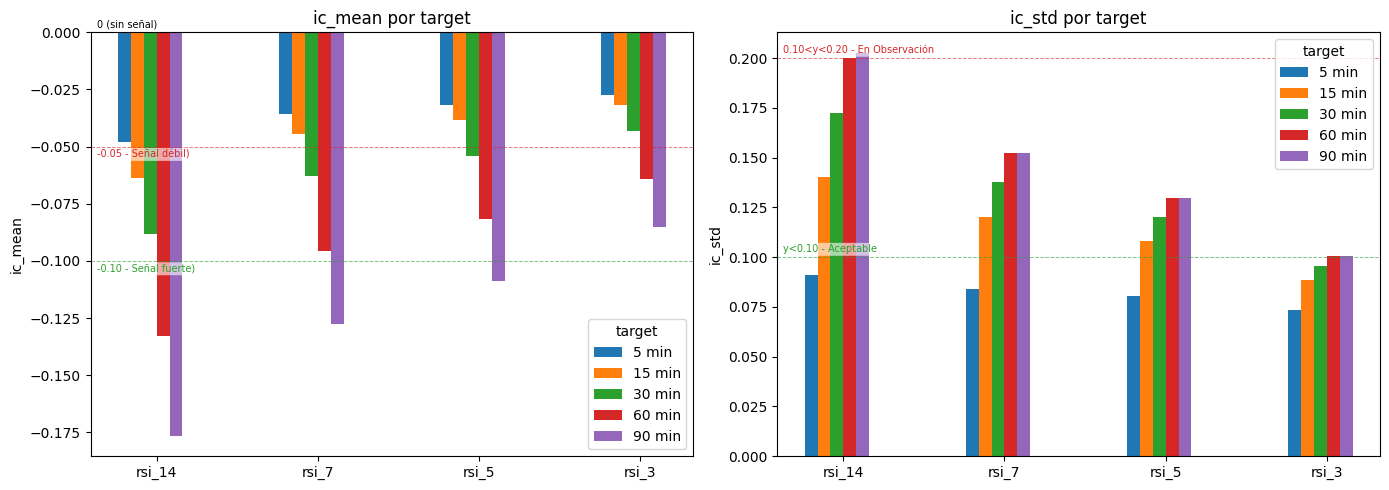

In [ ]:
plot_ic_mean_std(IC_rsi, sentido = 'reversión')

#### 3.1.1. Análisis

1. Tendencia general

    - En todos los casos el IC_mean es negativo, es decir, el RSI se comporta como un indicador de reversión (cuando sube mucho, suelen venir retornos negativos, y viceversa).  
    - La magnitud del IC (valor absoluto) aumenta con horizontes de predicción más largos:
      - Muy débil a 5 min (≈ -0.02 a -0.05).  
      - Moderado a 30 min (≈ -0.04 a -0.09).  
      - Más claro a 60 min (≈ -0.06 a -0.13).  
      - Más fuerte a 90 min (≈ -0.09 a -0.18).  

    El RSI capta excesos de precio que corrigen con cierto retraso, no señales inmediatas.

2. Comparación entre variantes de RSI

    - RSI_14
      - Siempre el de mayor magnitud negativa (mejor señal contrarian).  
      - Ejemplo: IC_mean = -0.176 a 90 min.  
      - **Problema:** también es el más volátil (`ic_std` alto, ~0.20). Señal potente pero inestable.  

    - RSI_7  
      - Señal más moderada que RSI_14, pero más estable (`ic_std` menor, ~0.15).  
      - Puede ser un **mejor balance entre señal y estabilidad**.  

    - RSI_5  
      - Señal más débil, aunque algo más consistente (`ic_std` ~0.12–0.13).  
      - Puede sumar en conjunto, pero individualmente es limitado.  

    - RSI_3  
      - Señal casi nula en horizontes cortos, apenas moderada en 90 min (IC_mean ≈ -0.085).  
      - En la práctica, es ruido estable.  




#### 3.1.2. Conclusiones

- El RSI es útil como feature contrarian intradía, especialmente en horizontes de 30–90 min.  
- RSI_14: el más potente pero más volátil → conviene validarlo dentro de un modelo con otros factores.  
- RSI_7: menos fuerte pero más estable → mejor candidato si buscás robustez.  
- RSI_5 y RSI_3: débiles, probablemente descartables salvo en combinaciones.  

Para un modelo predictivo, los candidatos más sólidos son RSI_14 y RSI_7 en horizontes de 30 a 90 minutos.  

Por ahora, para nuestro proyecto conservamores los RSI_7 y RSI_14 en los horizontes de 30 y 60min.


### 3.2. **Momentum**

In [ ]:
mnq_momentum, momentum_cols = calcular_momentum()

In [ ]:
IC_momentum_5 = calcular_IC(mnq_momentum, 'target_return_5', momentum_cols)
IC_momentum_15 = calcular_IC(mnq_momentum, 'target_return_15', momentum_cols)
IC_momentum_30 = calcular_IC(mnq_momentum, 'target_return_30', momentum_cols)
IC_momentum_60 = calcular_IC(mnq_momentum, 'target_return_60', momentum_cols)
IC_momentum_90 = calcular_IC(mnq_momentum, 'target_return_90', momentum_cols)

In [ ]:
IC_momentum = [IC_momentum_5, IC_momentum_15, IC_momentum_30, IC_momentum_60, IC_momentum_90]
IC_momentum = reduce(lambda left, right: pd.merge(left, right, on="indicador", how="inner"), IC_momentum)

In [ ]:
IC_momentum

,indicador,ic_mean_5min,ic_std_5min,ic_mean_15min,ic_std_15min,ic_mean_30min,ic_std_30min,ic_mean_60min,ic_std_60min,ic_mean_90min,ic_std_90min
0,momentum_10,-0.030399,0.089497,-0.037058,0.120910,-0.053240,0.129744,-0.082424,0.136893,-0.112294,0.134865
1,momentum_5,-0.024815,0.079389,-0.028953,0.090813,-0.040213,0.093976,-0.060545,0.097287,-0.082049,0.096481
2,momentum_3,-0.021038,0.068409,-0.024335,0.071229,-0.032888,0.073411,-0.048521,0.075627,-0.065862,0.075367


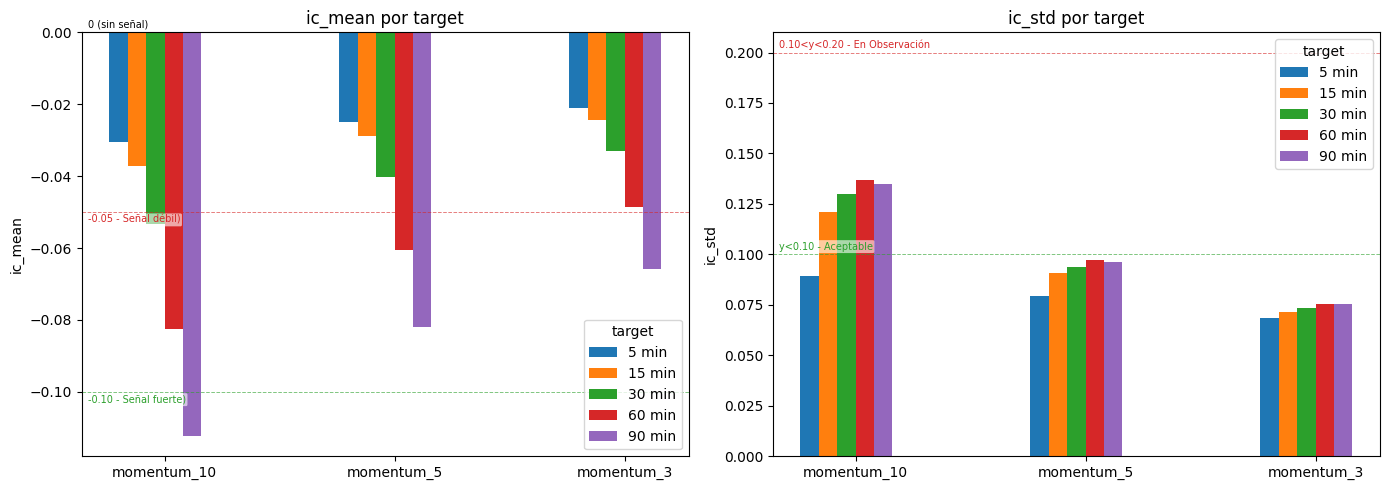

In [ ]:
plot_ic_mean_std(IC_momentum, sentido = 'reversión')

#### 3.2.1. Análisis



1. Tendencia general

    - Todos los valores de `ic_mean` son negativos, igual que con RSI, el momentum también se comporta como factor de reversión en intradía.  
    - El poder predictivo crece con horizontes más largos (IC más negativo a 60 y 90 min).  
    - A 5–15 min la señal es muy débil, cercana al ruido.

2. Comparación entre ventanas

    - `momentum_10`: Siempre el más fuerte (ej: -0.112 en 90 min).  
    - `momentum_5`: Señal intermedia.  
    - `momentum_3`: El más débil en todos los horizontes.  
      
      La jerarquía es clara: **momentum_10 > momentum_5 > momentum_3**.  

3. Estabilidad (IC_std)

    - Los valores de `ic_std` son relativamente bajos (≈0.07–0.13), lo que indica que el momentum es más estable que el RSI.  
    - Esto lo hace un candidato interesante como feature, porque aunque la señal no sea tan fuerte, es más consistente.  




#### 3.2.1. Conclusiones

- El momentum actúa como indicador contrarian intradía, no como confirmación de tendencia.  
- La señal es más clara en horizontes de 60–90 minutos, siendo `momentum_10` el más informativo.
- A diferencia del RSI, el momentum es más estable (menor `ic_std`), lo que puede hacerlo más confiable como feature en un modelo predictivo.  

Para nuestros modelos, los candidatos principales serían `momentum_10` y `momentum_5` en horizontes de 30–90 min.


### 3.3. **Relación de volumen actual vs. su promedio reciente**

In [ ]:
mnq_volumen, volumen_cols = calcular_volumen_ratio()

In [ ]:
IC_volumen_5 = calcular_IC(mnq_volumen, 'target_return_5', volumen_cols)
IC_volumen_15 = calcular_IC(mnq_volumen, 'target_return_15', volumen_cols)
IC_volumen_30 = calcular_IC(mnq_volumen, 'target_return_30', volumen_cols)
IC_volumen_60 = calcular_IC(mnq_volumen, 'target_return_60', volumen_cols)
IC_volumen_90 = calcular_IC(mnq_volumen, 'target_return_90', volumen_cols)

In [ ]:
IC_volumen= [IC_volumen_5, IC_volumen_15, IC_volumen_30, IC_volumen_60, IC_volumen_90]
IC_volumen = reduce(lambda left, right: pd.merge(left, right, on="indicador", how="inner"), IC_volumen)

In [ ]:
IC_volumen

,indicador,ic_mean_5min,ic_std_5min,ic_mean_15min,ic_std_15min,ic_mean_30min,ic_std_30min,ic_mean_60min,ic_std_60min,ic_mean_90min,ic_std_90min
0,volume_ratio_15,0.002677,0.067676,0.002168,0.073051,0.005303,0.064345,0.008234,0.061299,0.008981,0.065214
1,volume_ratio_20,0.002613,0.070534,0.002145,0.084182,0.004812,0.078493,0.008283,0.076798,0.009805,0.082234
2,volume_ratio_30,0.003651,0.074682,0.003757,0.098544,0.005131,0.103872,0.009223,0.107169,0.013099,0.117743
3,volume_ratio_60,0.007878,0.084866,0.009890,0.125386,0.012333,0.159849,0.018067,0.195873,0.025186,0.215884
4,volume_ratio_90,0.010425,0.093839,0.014646,0.149240,0.018750,0.200179,0.027270,0.265302,0.039920,0.303393


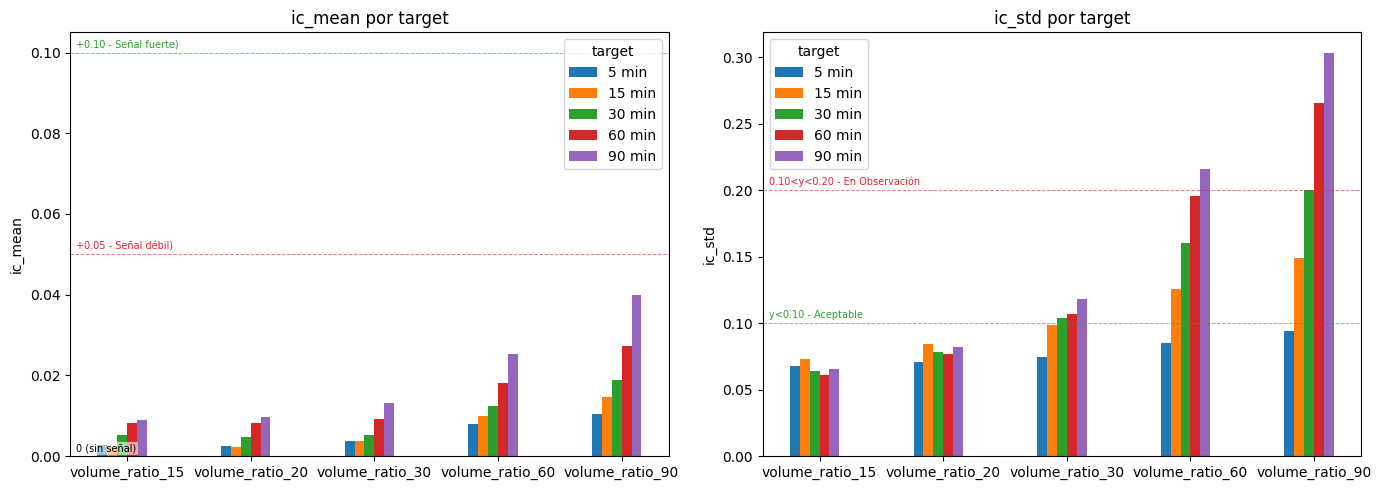

In [ ]:
plot_ic_mean_std(IC_volumen)

#### 3.3.1. Análisis


1. Magnitud del IC_mean

    - Todos los valores son positivos pero muy bajos (0.002–0.04).
    - Incluso en horizontes largos (90 min) el mejor `ic_mean` apenas llega a 0.0399, muy por debajo del umbral de 0.05 que suele considerarse el mínimo para una señal débil pero útil.
    - Esto implica que, por sí solo, el volumen ratio tiene poder predictivo muy limitado.

2. Tendencia con el horizonte

    - La señal mejora un poco a medida que aumenta el target (de 5 a 90 min).
    - Ejemplo: `volume_ratio_15` sube de 0.002 a 0.009, y `volume_ratio_90` pasa de 0.010 a 0.040.
    - Aun así, la ganancia no es suficiente para convertirlo en un factor fuerte.

3. Estabilidad (IC_std)

    - El ic_std aumenta significativamente con el horizonte, la señal se vuelve más volátil y menos confiable.
    - Ejemplo: `volume_ratio_90` pasa de 0.093 (5 min) a 0.303 (90 min).
    - Esto refuerza que el factor no es robusto: la señal, aunque leve, no es consistente.

#### 3.3.2. Conclusiones

- El volume ratio no alcanza niveles de `ic_mean` que lo hagan atractivo como predictor individual.
- El hecho de que los IC sean positivos sugiere que sigue la tendencia (no reversión), pero la señal es demasiado débil.
- El crecimiento de la desviación `ic_std` con horizontes largos indica que la poca señal que tiene se vuelve inestable cuanto más se amplía la ventana de predicción.
- El volume ratio, por sí solo, no debería considerarse un feature prioritario: los `ic_mean` son demasiado bajos y los `ic_std` demasiado altos en horizontes largos.

En conclusión, aunque el `volume_ratio_90` es el más fuerte de la familia, pero aún así no pasa de ser ruido débil. El ratio de volumen no parece un buen candidato aislado para predecir retornos intradía.

### 3.4. **MACD diferencial (señal de cruce)**

In [ ]:
mnq_macd, macd_cols = calcular_macd()

In [ ]:
IC_macd_5 = calcular_IC(mnq_macd, 'target_return_5', macd_cols)
IC_macd_15 = calcular_IC(mnq_macd, 'target_return_15', macd_cols)
IC_macd_30 = calcular_IC(mnq_macd, 'target_return_30', macd_cols)
IC_macd_60 = calcular_IC(mnq_macd, 'target_return_60', macd_cols)
IC_macd_90 = calcular_IC(mnq_macd, 'target_return_90', macd_cols)

In [ ]:
IC_macd = [IC_macd_5, IC_macd_15, IC_macd_30, IC_macd_60, IC_macd_90]
IC_macd = reduce(lambda left, right: pd.merge(left, right, on="indicador", how="inner"), IC_macd)

In [ ]:
IC_macd

,indicador,ic_mean_5min,ic_std_5min,ic_mean_15min,ic_std_15min,ic_mean_30min,ic_std_30min,ic_mean_60min,ic_std_60min,ic_mean_90min,ic_std_90min
0,macd,-0.016788,0.095064,-0.011999,0.130968,-0.01801,0.135153,-0.026394,0.122985,-0.035572,0.121715


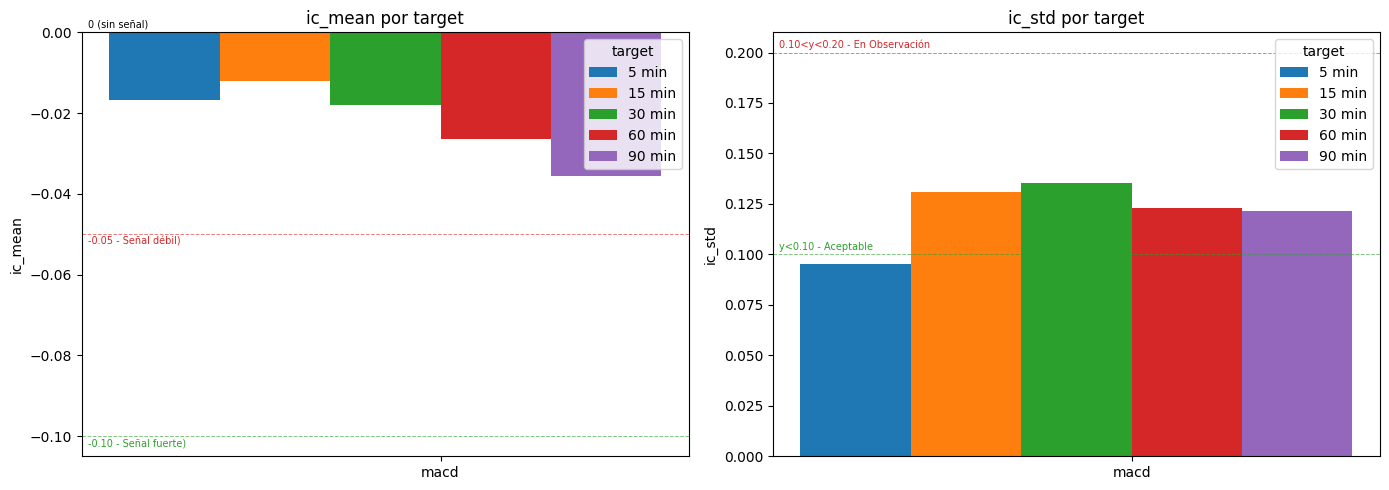

In [ ]:
plot_ic_mean_std(IC_macd, sentido = 'reversión')

#### 3.4.1. Análisis

1. Señal contrarian
    - Todos los IC_mean son negativos, lo que implica que el MACD se comporta como indicador de reversión en estos datos intradía.  
    - Valores altos del MACD tienden a preceder retornos negativos, y viceversa.  

2. Magnitud del IC
    - La señal es débil en horizontes cortos (≈ -0.01 a -0.02 en 5–30 min).  
    - Gana fuerza en horizontes más largos, llegando a -0.036 en 90 min.  
    - Aun así, está por debajo de 0.05, por lo que se considera débil o modesta.  

3. Estabilidad (IC_std)
    - Los valores de ic_std están en el rango 0.095–0.135, bastante consistentes entre horizontes.  
    - Esto indica que la señal, aunque débil, es relativamente estable en el tiempo.  

#### 3.4.2. Conclusiones

  - El MACD muestra un comportamiento contrarian intradía, pero con poder predictivo limitado.  
  - Su mejor desempeño se observa en horizontes de 60–90 minutos, aunque sin alcanzar valores de IC que lo conviertan en un factor fuerte.  
  - La relativa estabilidad del ic_std sugiere que el MACD puede servir como feature complementario, aunque no debería usarse como predictor principal.  

Vamos a conservar el MACD como un feature secundario, sobre todo en horizontes largos (60–90 minutos), donde aunque su señal sigue siendo débil, puede aportar cierta información adicional. Su mayor valor podría estar en la diversidad que introduce al combinarse con otros indicadores como RSI o Momentum.

### 3.5. **Distancia del precio actual a su EMA (15, 20 y 30 minutos)**

In [ ]:
mnq_ema, ema_cols = calcular_ema()

In [ ]:
IC_ema_5 = calcular_IC(mnq_ema, 'target_return_5', ema_cols)
IC_ema_15 = calcular_IC(mnq_ema, 'target_return_15', ema_cols)
IC_ema_30 = calcular_IC(mnq_ema, 'target_return_30', ema_cols)
IC_ema_60 = calcular_IC(mnq_ema, 'target_return_60', ema_cols)
IC_ema_90 = calcular_IC(mnq_ema, 'target_return_90', ema_cols)

In [ ]:
IC_ema = [IC_ema_5, IC_ema_15, IC_ema_30, IC_ema_60, IC_ema_90]
IC_ema = reduce(lambda left, right: pd.merge(left, right, on="indicador", how="inner"), IC_ema)

In [ ]:
IC_ema

,indicador,ic_mean_5min,ic_std_5min,ic_mean_15min,ic_std_15min,ic_mean_30min,ic_std_30min,ic_mean_60min,ic_std_60min,ic_mean_90min,ic_std_90min
0,price_ema15,-0.035159,0.087529,-0.043786,0.126582,-0.063647,0.144942,-0.097952,0.158557,-0.133444,0.155646
1,price_ema20,-0.039083,0.089954,-0.049943,0.134797,-0.072318,0.158994,-0.111052,0.177833,-0.151308,0.174142
2,price_ema30,-0.046042,0.092732,-0.061355,0.144275,-0.087274,0.176637,-0.132857,0.203450,-0.180860,0.199570
3,price_ema60,-0.061367,0.094665,-0.088275,0.152986,-0.122167,0.195361,-0.182629,0.232203,-0.246481,0.232038


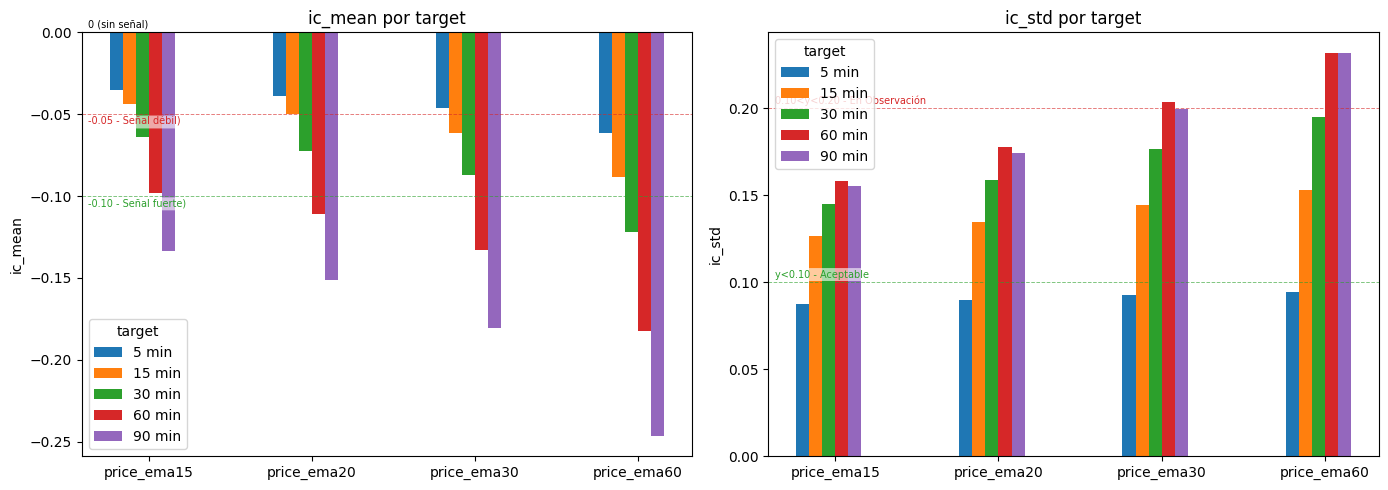

In [ ]:
plot_ic_mean_std(IC_ema, sentido = 'reversión')

#### 3.5.1. Análisis

1. Señal contrarian  
  Todos los IC_mean son negativos. Igual que RSI y MACD, las EMA se comportan como indicadores de reversión en intradía: precios alejados de la media tienden a revertirse.

2. Magnitud de la señal  
    - La fuerza del IC aumenta de forma clara con el horizonte de predicción.  
    - En 30 min, ya se observan valores en torno a -0.06 a -0.12 (moderados).  
    - En 60 y 90 min, la señal se vuelve fuerte: hasta -0.246 con EMA60 a 90 min.  
    - Son de los valores más bajos observados hasta ahora, lo que implica mayor poder predictivo contrarian.  

3. Comparación entre longitudes de EMA  
    - EMA más largas (30 y 60) capturan mejor la reversión, con IC_mean más negativo.  
    - EMA cortas (15 y 20) muestran señal, pero más débil.  
    - Existe un patrón claro: a mayor ventana de EMA, mayor poder predictivo contrarian.  

4. Estabilidad (IC_std)  
    - El ic_std también aumenta con horizontes largos, llegando a 0.23 en EMA60 a 90 min.  
    - Esto implica que, aunque la señal es fuerte, es más volátil.  
    - Aun así, las EMA largas combinan un balance interesante entre fuerza de señal y estabilidad aceptable.  


#### 3.5.2. Conclusiones

- Las EMA muestran un comportamiento contrarian fuerte en datos intradía.  
- EMA30 y EMA60 son los mejores candidatos como features, especialmente para horizontes de 30 a 90 minutos.  
- Aunque el ic_std sube, los valores absolutos del IC_mean son suficientemente grandes como para considerar estas medias móviles como factores prioritarios.  
- EMA15 y EMA20 pueden descartarse o quedar como secundarios, dado que aportan menos información.  

### 3.6. **%K Estocástico**

In [ ]:
mnq_stoch, stoch_cols = calcular_stochastic()

In [ ]:
IC_stoch_5 = calcular_IC(mnq_stoch, 'target_return_5', stoch_cols)
IC_stoch_15 = calcular_IC(mnq_stoch, 'target_return_15', stoch_cols)
IC_stoch_30 = calcular_IC(mnq_stoch, 'target_return_30', stoch_cols)
IC_stoch_60 = calcular_IC(mnq_stoch, 'target_return_60', stoch_cols)
IC_stoch_90 = calcular_IC(mnq_stoch, 'target_return_90', stoch_cols)

In [ ]:
IC_stoch = [IC_stoch_5, IC_stoch_15, IC_stoch_30, IC_stoch_60, IC_stoch_90]
IC_stoch = reduce(lambda left, right: pd.merge(left, right, on="indicador", how="inner"), IC_stoch)
IC_stoch

,indicador,ic_mean_5min,ic_std_5min,ic_mean_15min,ic_std_15min,ic_mean_30min,ic_std_30min,ic_mean_60min,ic_std_60min,ic_mean_90min,ic_std_90min
0,stoch_k_14,-0.032586,0.084620,-0.040784,0.117110,-0.059042,0.126565,-0.088641,0.134849,-0.117819,0.135689
1,stoch_k_20,-0.036599,0.087381,-0.047908,0.128751,-0.070241,0.147213,-0.105944,0.159769,-0.141962,0.160943
2,stoch_k_30,-0.044361,0.090401,-0.061374,0.139616,-0.087019,0.170373,-0.132252,0.192868,-0.175458,0.193385


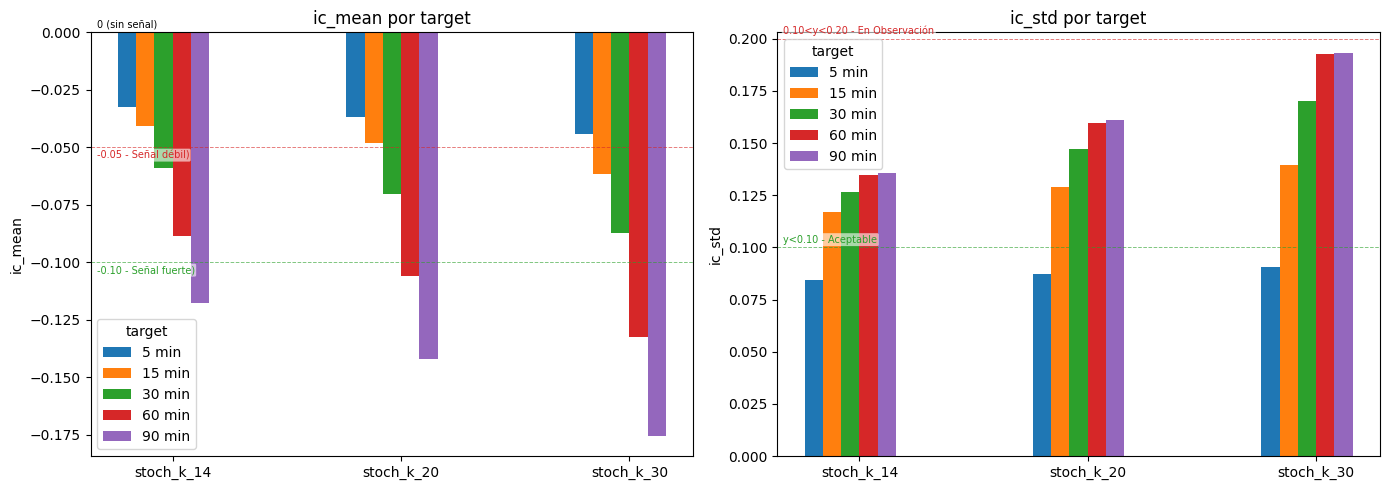

In [ ]:
plot_ic_mean_std(IC_stoch, sentido = 'reversión')

#### 3.6.1. Análisis


1. Señal contrarian  
  Todos los IC_mean son negativos. Igual que el RSI, las EMA y el MACD, el estocástico actúa como indicador de reversión intradía: lecturas altas suelen anticipar retornos negativos y lecturas bajas anticipan retornos positivos.

2. Magnitud de la señal  
    - A 5 y 15 minutos la señal es débil (IC_mean entre -0.03 y -0.06).  
    - A 30 minutos se hace más clara (≈ -0.06 a -0.09).  
    - A 60 y 90 minutos se fortalece bastante: hasta -0.176 con Stoch K 30 en 90 min.  
    - Esto lo ubica como un factor contrarian fuerte en horizontes largos.  

3. Comparación entre longitudes  
    - Stoch K más largos (20 y 30) muestran mayor magnitud negativa del IC.  
    - La jerarquía es clara: stoch_k_30 > stoch_k_20 > stoch_k_14.  
    - A medida que aumenta la longitud, la señal mejora en fuerza, aunque también crece la volatilidad.  

4. Estabilidad (IC_std)  
    - El ic_std aumenta conforme crece el horizonte y la longitud de cálculo.  
    - Valores van desde 0.08 en horizontes cortos hasta ≈0.19 en stoch_k_30 a 90 min.  
    - Esto implica que la señal, aunque fuerte, es más variable en el tiempo.  

#### 3.6.2. Conclusiones

- El estocástico es un buen indicador contrarian intradía, especialmente en horizontes de 30 a 90 minutos.  
- Stoch K 30 es el más fuerte en poder predictivo, aunque también el más volátil.  
- Stoch K 20 ofrece un balance intermedio entre fuerza y estabilidad.  
- Stoch K 14 queda rezagado en comparación, con señal más débil.

Para nuestro modelo predictivo:  

- Conservaremos el `stoch_k_20` como feature principal, ya que ofrece un equilibrio razonable entre poder predictivo y estabilidad.  
- Usaremos `stoch_k_30` como feature secundario, para aportar fuerza adicional en horizontes de 60–90 minutos, con la precaución de que su señal es más volátil.  
- Descartamos `stoch_k_14`, dado que su aporte es más limitado frente a las otras variantes.  

### 3.7.**%B de Bollinger (Bollinger Band Percent)**


In [ ]:
mnq_bollinger, bollinger_cols = calcular_bollinger()

In [ ]:
IC_bollinger_5 = calcular_IC(mnq_bollinger, 'target_return_5', bollinger_cols)
IC_bollinger_15 = calcular_IC(mnq_bollinger, 'target_return_15', bollinger_cols)
IC_bollinger_30 = calcular_IC(mnq_bollinger, 'target_return_30', bollinger_cols)
IC_bollinger_60 = calcular_IC(mnq_bollinger, 'target_return_60', bollinger_cols)
IC_bollinger_90 = calcular_IC(mnq_bollinger, 'target_return_90', bollinger_cols)

In [ ]:
IC_bollinger = [IC_bollinger_5, IC_bollinger_15, IC_bollinger_30, IC_bollinger_60, IC_bollinger_90]
IC_bollinger = reduce(lambda left, right: pd.merge(left, right, on="indicador", how="inner"), IC_bollinger)
IC_bollinger

,indicador,ic_mean_5min,ic_std_5min,ic_mean_15min,ic_std_15min,ic_mean_30min,ic_std_30min,ic_mean_60min,ic_std_60min,ic_mean_90min,ic_std_90min
0,bb_15_15,-0.031627,0.084331,-0.040562,0.115213,-0.055575,0.124482,-0.084034,0.132530,-0.112638,0.133566
1,bb_20_15,-0.034201,0.087964,-0.045251,0.125837,-0.063539,0.141046,-0.097252,0.152624,-0.130950,0.154313
2,bb_30_15,-0.040472,0.092048,-0.055340,0.138873,-0.078302,0.165005,-0.121111,0.185646,-0.160935,0.186967
3,bb_60_15,-0.055643,0.100329,-0.079935,0.160037,-0.115424,0.207046,-0.175367,0.245968,-0.230213,0.247842
4,bb_15_20,-0.031627,0.084331,-0.040562,0.115213,-0.055575,0.124482,-0.084034,0.132530,-0.112638,0.133566
5,bb_20_20,-0.034201,0.087964,-0.045251,0.125837,-0.063539,0.141046,-0.097252,0.152624,-0.130950,0.154313
6,bb_30_20,-0.040472,0.092048,-0.055340,0.138873,-0.078302,0.165005,-0.121111,0.185646,-0.160935,0.186967
7,bb_60_20,-0.055643,0.100329,-0.079935,0.160037,-0.115424,0.207046,-0.175367,0.245968,-0.230213,0.247842
8,bb_15_25,-0.031627,0.084331,-0.040562,0.115213,-0.055575,0.124482,-0.084034,0.132530,-0.112638,0.133566
9,bb_20_25,-0.034201,0.087964,-0.045251,0.125837,-0.063539,0.141046,-0.097252,0.152624,-0.130950,0.154313


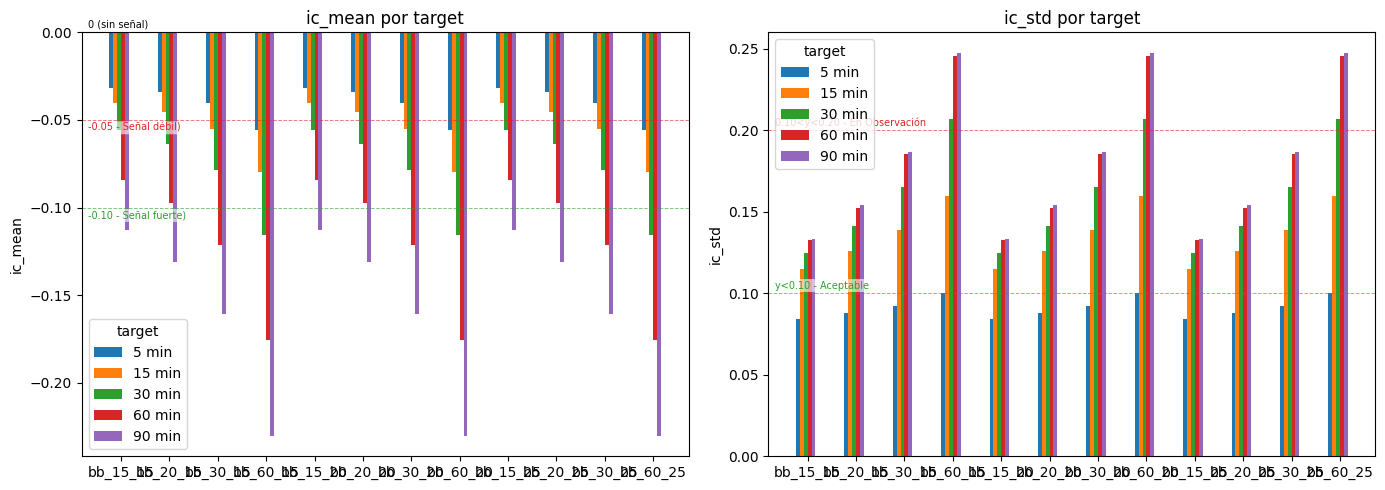

In [ ]:
plot_ic_mean_std(IC_bollinger, sentido = 'reversión')

Al analizar los resultados iniciales se observa que, para los distintos valores de desviación estándar (15, 20, 25), el cambio en el ancho de la banda no altera los resultados: los IC obtenidos son idénticos para cada longitud de media móvil (15, 20, 30, 60).

Esto indica que el parámetro verdaderamente relevante es la longitud de la media móvil, mientras que la desviación estándar no aporta diferencias significativas.

Por ello, se rehace el cálculo considerando únicamente una desviación estándar de 20 (equivalente al 2%).

In [ ]:
mnq_bollinger, bollinger_cols = calcular_bollinger_resume()

In [ ]:
IC_bollinger_5 = calcular_IC(mnq_bollinger, 'target_return_5', bollinger_cols)
IC_bollinger_15 = calcular_IC(mnq_bollinger, 'target_return_15', bollinger_cols)
IC_bollinger_30 = calcular_IC(mnq_bollinger, 'target_return_30', bollinger_cols)
IC_bollinger_60 = calcular_IC(mnq_bollinger, 'target_return_60', bollinger_cols)
IC_bollinger_90 = calcular_IC(mnq_bollinger, 'target_return_90', bollinger_cols)

In [ ]:
IC_bollinger = [IC_bollinger_5, IC_bollinger_15, IC_bollinger_30, IC_bollinger_60, IC_bollinger_90]
IC_bollinger = reduce(lambda left, right: pd.merge(left, right, on="indicador", how="inner"), IC_bollinger)
IC_bollinger

,indicador,ic_mean_5min,ic_std_5min,ic_mean_15min,ic_std_15min,ic_mean_30min,ic_std_30min,ic_mean_60min,ic_std_60min,ic_mean_90min,ic_std_90min
0,bb_15,-0.031627,0.084331,-0.040562,0.115213,-0.055575,0.124482,-0.084034,0.132530,-0.112638,0.133566
1,bb_20,-0.034201,0.087964,-0.045251,0.125837,-0.063539,0.141046,-0.097252,0.152624,-0.130950,0.154313
2,bb_30,-0.040472,0.092048,-0.055340,0.138873,-0.078302,0.165005,-0.121111,0.185646,-0.160935,0.186967
3,bb_60,-0.055643,0.100329,-0.079935,0.160037,-0.115424,0.207046,-0.175367,0.245968,-0.230213,0.247842


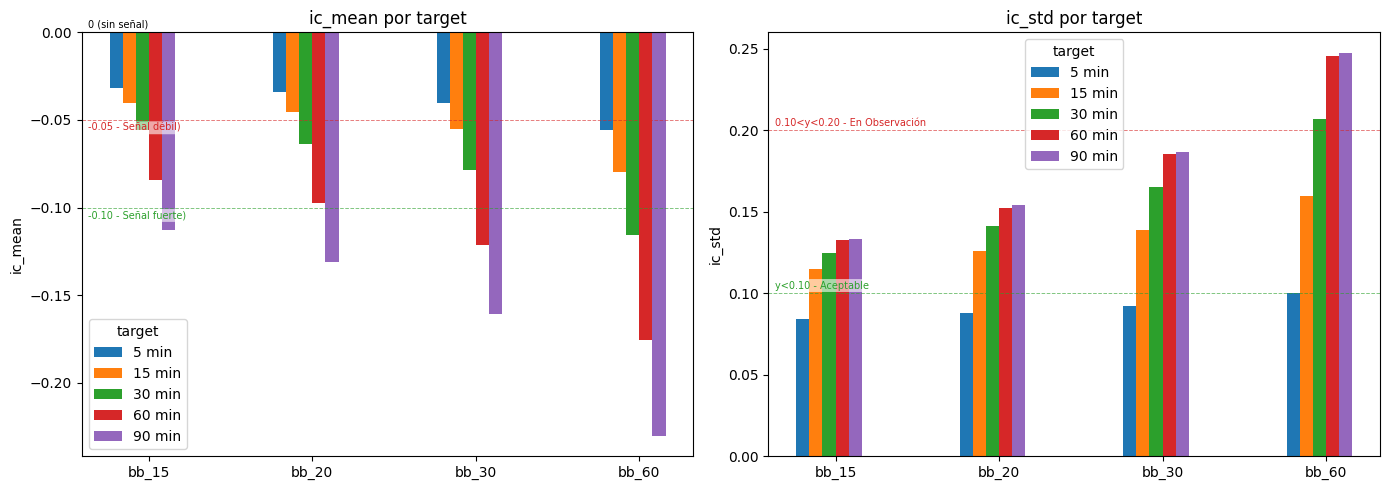

In [ ]:
plot_ic_mean_std(IC_bollinger, sentido = 'reversión')

#### 3.7.1. Análisis

1. Señal contrarian  
Todos los IC_mean son negativos, lo que confirma que las Bollinger funcionan como indicadores de reversión intradía: cuando el precio se aleja mucho de la banda, tiende a revertirse.

2. Magnitud del IC  
    - A 5–15 min la señal es débil (IC ≈ -0.03 a -0.05).  
    - En 30 min se vuelve más clara (≈ -0.05 a -0.08).  
    - En 60–90 min la señal se hace fuerte: hasta -0.23 en bb_60 a 90 min, uno de los valores más grandes observados entre todos los indicadores calculados.  
    - Esto posiciona a las Bollinger largas como de los factores con mayor poder predictivo contrarian.  

3. Estabilidad (IC_std)  
    - El ic_std crece conforme aumenta el horizonte y la longitud de la media.  
    - Va desde ≈0.08–0.10 en 5 min hasta ≈0.24–0.25 en bb_60 a 90 min.  
    - Esto indica que la señal es fuerte pero también volátil en horizontes largos.  

4. Comparación entre longitudes  
    - bb_60 es claramente la más potente, con la mayor magnitud de IC en todos los horizontes.  
    - bb_30 también muestra buena señal, aunque más moderada.  
    - bb_15 y bb_20 aportan algo, pero se quedan cortas frente a bb_30 y bb_60.  


#### 3.7.2. Conclusiones

- Las Bollinger largas (bb_30 y bb_60) son las que realmente destacan como factores predictivos.  
- bb_60 es la más potente, aunque más volátil.  
- bb_30 ofrece un balance razonable entre señal fuerte y estabilidad.  
- bb_15 y bb_20 pueden considerarse secundarios, ya que su aporte es menor en horizontes de 30–90 min.  

Para nuestro modelo vamos a conservar bb_30 y bb_60 como features prioritarios para el modelo, en especial si el target está en horizontes de 30–90 minutos.  

Y opcionalmente mantendremos bb_15 o bb_20 como secundarios, si se desea probar combinaciones, aunque su poder predictivo es limitado.  

### 3.8. **ATR normalizado (Average True Range / precio)**

In [ ]:
mnq_atr, atr_cols = calcular_atr()

In [ ]:
IC_atr_5 = calcular_IC(mnq_atr, 'target_return_5', atr_cols)
IC_atr_15 = calcular_IC(mnq_atr, 'target_return_15', atr_cols)
IC_atr_30 = calcular_IC(mnq_atr, 'target_return_30', atr_cols)
IC_atr_60 = calcular_IC(mnq_atr, 'target_return_60', atr_cols)
IC_atr_90 = calcular_IC(mnq_atr, 'target_return_90', atr_cols)

,indicador,ic_mean_5min,ic_std_5min,ic_mean_15min,ic_std_15min,ic_mean_30min,ic_std_30min,ic_mean_60min,ic_std_60min,ic_mean_90min,ic_std_90min
0,atr_norm_30,0.049151,0.099941,0.075653,0.172372,0.094745,0.242809,0.111763,0.321337,0.112498,0.384501
1,atr_norm_5,0.042173,0.100884,0.063027,0.163333,0.082025,0.222873,0.105509,0.288141,0.115841,0.332672
2,atr_norm_20,0.047711,0.101092,0.073152,0.172923,0.092344,0.242245,0.111898,0.317576,0.115729,0.373674
3,atr_norm_14,0.046565,0.101018,0.070678,0.171679,0.089886,0.238898,0.111374,0.311678,0.117026,0.363452
4,atr_norm_10,0.045327,0.101211,0.068363,0.169652,0.087641,0.234549,0.110074,0.304811,0.117358,0.353332


In [ ]:
IC_atr = [IC_atr_5, IC_atr_15, IC_atr_30, IC_atr_60, IC_atr_90]
IC_atr = reduce(lambda left, right: pd.merge(left, right, on="indicador", how="inner"), IC_atr)
IC_atr

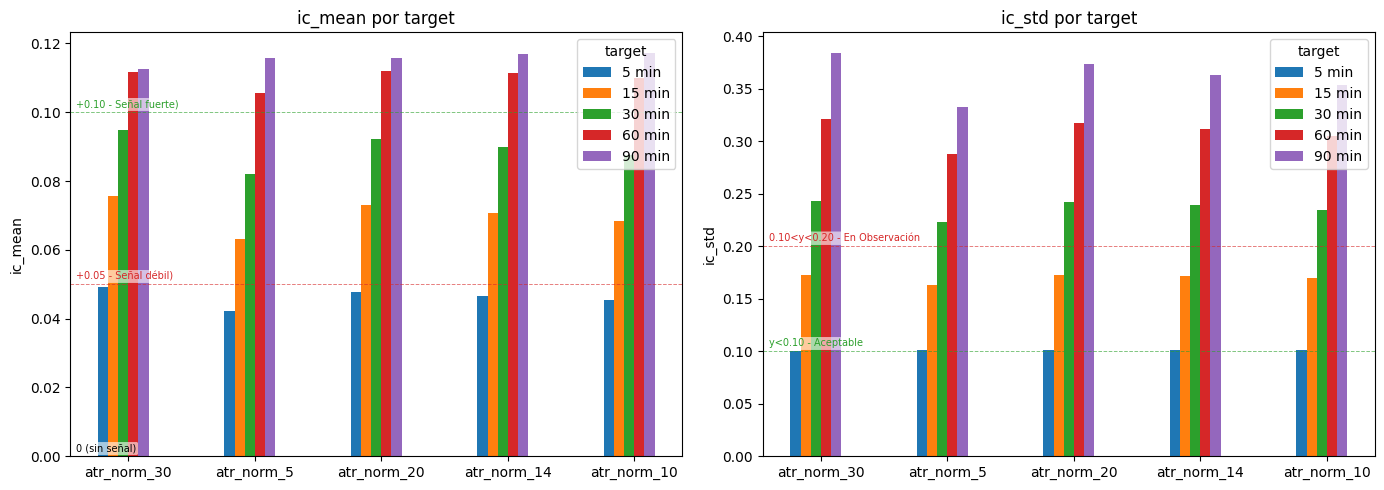

In [ ]:
plot_ic_mean_std(IC_atr)

Al comparar distintas longitudes del ATR (5, 10, 14, 20 y 30) se observa que los valores de IC_mean son muy similares entre ellas, sin un patrón claro que favorezca a una ventana en particular.  

Por ejemplo, atr_norm_5 y atr_norm_30 alcanzan valores casi idénticos en el horizonte de 90 minutos (≈0.115).  

Dado que no existe una diferencia significativa en el desempeño entre longitudes, y la desviación estándar es practicamente la misma para todas las ventanas, se decide rehacer el cálculo manteniendo únicamente la ventana clásica de 14 períodos, ampliamente utilizada en análisis técnico.


In [ ]:
mnq_atr, atr_cols = calcular_atr_14()
IC_atr_5 = calcular_IC(mnq_atr, 'target_return_5', atr_cols)
IC_atr_15 = calcular_IC(mnq_atr, 'target_return_15', atr_cols)
IC_atr_30 = calcular_IC(mnq_atr, 'target_return_30', atr_cols)
IC_atr_60 = calcular_IC(mnq_atr, 'target_return_60', atr_cols)
IC_atr_90 = calcular_IC(mnq_atr, 'target_return_90', atr_cols)
IC_atr = [IC_atr_5, IC_atr_15, IC_atr_30, IC_atr_60, IC_atr_90]
IC_atr = reduce(lambda left, right: pd.merge(left, right, on="indicador", how="inner"), IC_atr)
IC_atr

,indicador,ic_mean_5min,ic_std_5min,ic_mean_15min,ic_std_15min,ic_mean_30min,ic_std_30min,ic_mean_60min,ic_std_60min,ic_mean_90min,ic_std_90min
0,atr_norm,0.046565,0.101018,0.070678,0.171679,0.089886,0.238898,0.111374,0.311678,0.117026,0.363452


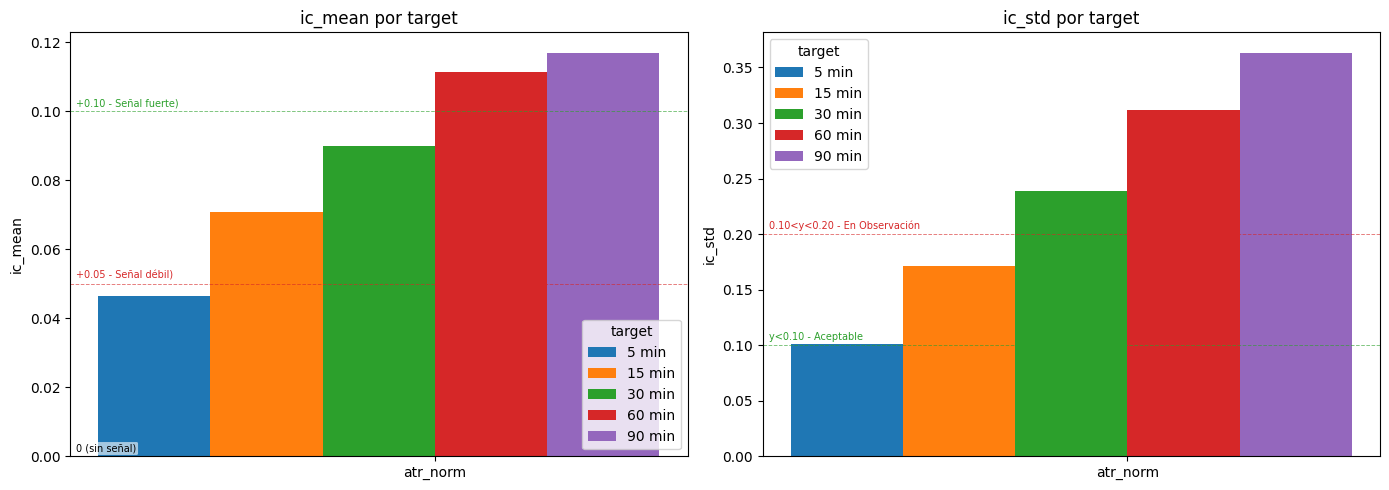

In [ ]:
plot_ic_mean_std(IC_atr)

#### 3.8.1. Análisis

- El IC_mean es positivo en todos los horizontes, lo que indica que el ATR normalizado actúa como un indicador de continuación, no de reversión.

- La señal se incrementa conforme aumenta el horizonte de predicción:  
  - 5 min ≈ 0.047 (débil)  
  - 15 min ≈ 0.071 (moderada)  
  - 30 min ≈ 0.090 (más clara)  
  - 60 min ≈ 0.111 (consistente)  
  - 90 min ≈ 0.117 (la más fuerte)  
  
- El ic_std también crece de forma notable, lo que indica mayor volatilidad y menor estabilidad de la señal en horizontes largos.  





#### 3.8.2. Conclusiones

- El ATR(14) normalizado aporta señal predictiva positiva moderada que mejora con horizontes de 30–90 minutos.  

- Si bien la magnitud no es muy alta (máx ≈0.12), puede ser un feature útil complementario, ya que captura información de volatilidad que otros factores no reflejan directamente.  

- Para nuestro modelo predictivo, conviene conservar atr_norm (14) como feature, especialmente si el foco está en retornos de 30 minutos o más.  



### 3.9. **ROC (Rate of Change)**

In [ ]:
mnq_roc, roc_cols = calcular_roc()

In [ ]:
IC_roc_5 = calcular_IC(mnq_roc, 'target_return_5', roc_cols)
IC_roc_15 = calcular_IC(mnq_roc, 'target_return_15', roc_cols)
IC_roc_30 = calcular_IC(mnq_roc, 'target_return_30', roc_cols)
IC_roc_60 = calcular_IC(mnq_roc, 'target_return_60', roc_cols)
IC_roc_90 = calcular_IC(mnq_roc, 'target_return_90', roc_cols)

In [ ]:
IC_roc = [IC_roc_5, IC_roc_15, IC_roc_30, IC_roc_60, IC_roc_90]
IC_roc = reduce(lambda left, right: pd.merge(left, right, on="indicador", how="inner"), IC_roc)
IC_roc

,indicador,ic_mean_5min,ic_std_5min,ic_mean_15min,ic_std_15min,ic_mean_30min,ic_std_30min,ic_mean_60min,ic_std_60min,ic_mean_90min,ic_std_90min
0,roc_5,-0.024815,0.079389,-0.028953,0.090813,-0.040213,0.093976,-0.060545,0.097287,-0.082049,0.096481
1,roc_10,-0.030399,0.089497,-0.037058,0.120910,-0.053240,0.129744,-0.082424,0.136893,-0.112294,0.134865
2,roc_20,-0.040085,0.094111,-0.050434,0.146672,-0.072436,0.171965,-0.113744,0.188340,-0.155541,0.185739
3,roc_30,-0.049258,0.097978,-0.067939,0.156783,-0.090506,0.194918,-0.140917,0.223404,-0.189233,0.222187
4,roc_60,-0.069024,0.102862,-0.106396,0.169990,-0.144933,0.224007,-0.202863,0.268266,-0.259803,0.276986


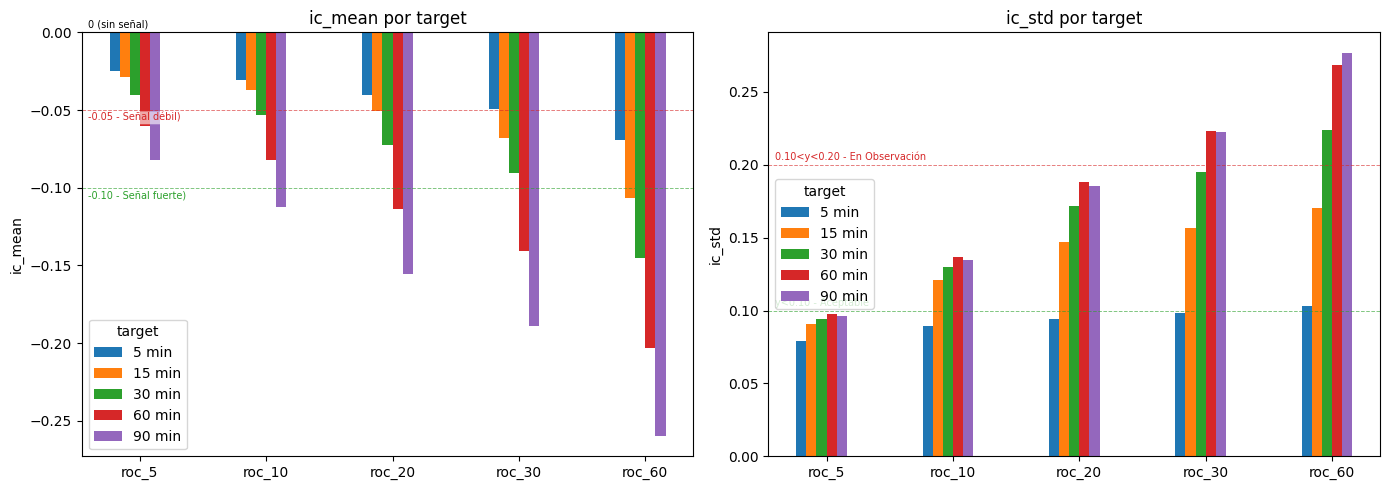

In [ ]:
plot_ic_mean_std(IC_roc, sentido ='reversión')

#### 3.9.1. Análisis

1. Señal del IC_mean  
    - Todos los valores son negativos, lo que indica que el ROC actúa como un indicador de reversión: cuando el precio sube demasiado rápido, tiende a revertirse.  
    - La magnitud del IC aumenta con la ventana de cálculo y con el horizonte de predicción:  
      - roc_5: señal débil (≈ -0.02 a -0.08)  
      - roc_10: señal algo más clara (≈ -0.03 a -0.11)  
      - roc_20: señal moderada (≈ -0.04 a -0.15)  
      - roc_30: señal fuerte en horizontes largos (≈ -0.05 a -0.19)  
      - roc_60: señal muy fuerte, llegando a ≈ -0.26 en 90 minutos  

2. Estabilidad (IC_std)  
    - El ic_std crece con la ventana y el horizonte.  
    - Pasa de ≈0.08–0.10 en roc_5 a ≈0.27 en roc_60.  
    - Los ROC largos capturan señales más intensas, pero también más volátiles.  

3. Comparación entre ventanas  
    - roc_5 y roc_10: aportan señales débiles, poco útiles.  
    - roc_20 y roc_30: muestran un buen balance entre fuerza de señal y estabilidad.  
    - roc_60: muy potente, pero con demasiada volatilidad.  


#### 3.9.2. Conclusiones

- El ROC confirma ser un indicador de reversión con mayor poder predictivo en horizontes largos.  

- Los mejores candidatos como features son roc_20 y roc_30, por su equilibrio entre fuerza de señal y estabilidad.  

- roc_60 puede considerarse de forma exploratoria, pero su alta inestabilidad lo hace menos recomendable.  

- roc_5 y roc_10 pueden descartarse por falta de señal útil.


### 3.10. Análisis en conjunto

Observemos todos los IC correspondiente a cada indicador técnico:

In [ ]:
IC_indicadores = pd.concat([IC_rsi, IC_momentum, IC_volumen, IC_macd, IC_ema, IC_stoch, IC_bollinger, IC_atr, IC_roc], axis=0)

In [ ]:
IC_indicadores

,indicador,ic_mean_5min,ic_std_5min,ic_mean_15min,ic_std_15min,ic_mean_30min,ic_std_30min,ic_mean_60min,ic_std_60min,ic_mean_90min,ic_std_90min
0,rsi_14,-0.047752,0.090891,-0.063626,0.140243,-0.088180,0.172203,-0.132798,0.200280,-0.176524,0.202798
1,rsi_7,-0.035864,0.084122,-0.044489,0.120114,-0.062888,0.137946,-0.095645,0.152071,-0.127395,0.152254
2,rsi_5,-0.031971,0.080349,-0.038342,0.108107,-0.053870,0.120162,-0.081721,0.129860,-0.108765,0.129949
3,rsi_3,-0.027416,0.073289,-0.031608,0.088640,-0.043152,0.095357,-0.064285,0.100617,-0.085241,0.100409
0,momentum_10,-0.030399,0.089497,-0.037058,0.120910,-0.053240,0.129744,-0.082424,0.136893,-0.112294,0.134865
1,momentum_5,-0.024815,0.079389,-0.028953,0.090813,-0.040213,0.093976,-0.060545,0.097287,-0.082049,0.096481
2,momentum_3,-0.021038,0.068409,-0.024335,0.071229,-0.032888,0.073411,-0.048521,0.075627,-0.065862,0.075367
0,volume_ratio_15,0.002677,0.067676,0.002168,0.073051,0.005303,0.064345,0.008234,0.061299,0.008981,0.065214
1,volume_ratio_20,0.002613,0.070534,0.002145,0.084182,0.004812,0.078493,0.008283,0.076798,0.009805,0.082234
2,volume_ratio_30,0.003651,0.074682,0.003757,0.098544,0.005131,0.103872,0.009223,0.107169,0.013099,0.117743


## 4. Guardado de dataset de indicadores técnicos

Previamente en las conclusiones de cada indicador técnico ya habíamos señalado que indicadores técnicos conservaremos:

In [20]:
columnas_base = ['date', 'open', 'high', 'low','close','volume']
columnas_target = ['target_return_30','target_return_60','target_return_90']
columnas_indicadores = ['rsi_14', 'rsi_7', 'momentum_10', 'momentum_5', 'macd', 'price_ema20', 'price_ema30', 'stoch_k_20', 'stoch_k_30',  'bb_20', 'bb_30', 'bb_60', 'atr_norm','roc_20', 'roc_30', 'roc_60']

In [ ]:
#Definir la lista de datasets
mnq_technical_indicators = [mnq_rsi, mnq_momentum, mnq_volumen, mnq_macd, mnq_ema,
              mnq_stoch, mnq_bollinger, mnq_atr, mnq_roc]

#Concatenar horizontalmente
mnq_technical_indicators = pd.concat(mnq_technical_indicators, axis=1)

#Eliminar columnas duplicadas (date, OHLCV, targets)
mnq_technical_indicators = mnq_technical_indicators.loc[:, ~mnq_technical_indicators.columns.duplicated()]

# Seleccionar columnas
mnq_technical_indicators = mnq_technical_indicators[ columnas_base + columnas_target + columnas_indicadores].copy()

In [ ]:
mnq_technical_indicators

,date,open,high,low,close,volume,target_return_5,target_return_15,target_return_30,target_return_60,...,price_ema30,stoch_k_20,stoch_k_30,bb_20,bb_30,bb_60,atr_norm,roc_20,roc_30,roc_60
datetime,,,,,,,,,,,,,,,,,,,,,
2019-12-23 08:00:00-05:00,2019-12-23,8734.00,8734.25,8733.75,8733.75,31,-0.000057,0.000143,0.000372,0.000401,...,0.000000e+00,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
2019-12-23 08:01:00-05:00,2019-12-23,8734.00,8734.25,8733.75,8734.00,16,-0.000029,0.000086,0.000286,0.000458,...,1.383501e-05,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
2019-12-23 08:02:00-05:00,2019-12-23,8734.00,8734.00,8733.25,8733.25,23,0.000057,0.000200,0.000315,0.000544,...,-4.640816e-05,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
2019-12-23 08:03:00-05:00,2019-12-23,8734.25,8734.50,8734.00,8734.00,23,-0.000057,0.000000,0.000315,0.000429,...,2.859176e-05,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
2019-12-23 08:04:00-05:00,2019-12-23,8734.00,8734.00,8733.50,8733.75,12,0.000029,0.000000,0.000458,0.000429,...,-2.535945e-08,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-13 15:56:00-04:00,2025-06-13,21624.50,21635.00,21613.50,21617.50,3251,NaN,NaN,NaN,NaN,...,-8.844700e-04,22.413793,22.413793,0.221020,0.206181,0.100025,0.000871,-0.073959,-0.055480,-0.203125
2025-06-13 15:57:00-04:00,2025-06-13,21616.50,21635.25,21615.75,21623.75,2201,NaN,NaN,NaN,NaN,...,-5.572032e-04,31.034483,31.034483,0.325051,0.306572,0.191181,0.000873,-0.156988,-0.025429,-0.182336
2025-06-13 15:58:00-04:00,2025-06-13,21623.25,21632.75,21616.50,21621.75,1859,NaN,NaN,NaN,NaN,...,-6.077556e-04,28.373702,28.275862,0.316411,0.280376,0.175104,0.000864,-0.219205,-0.024275,-0.102800


In [ ]:
# Guardar como Parquet
mnq_technical_indicators.to_parquet(f'{drive_path}/2_feature_engineering/mnq_technical_indicators.parquet')

## 5. Selección de mejores indicadores técnicos

### 4.1. Criterio: IC Score

Nuestro enfoque para la selección de los mejores indicadores técnicos es el **IC Score**

El IC score combina dos métricas clave para evaluar la calidad de un indicador técnicos:

- |IC medio|: mide el poder predictivo promedio del indicador (cuánto se asocia su valor con el retorno futuro).

- IC std: mide la volatilidad o inestabilidad del indicador a lo largo del tiempo (días en tu caso).

El cociente `|IC| / std` representa un signal-to-noise ratio: cuánta señal útil aporta el factor, ajustada por su variabilidad diaria.

Esto permite seleccionar indicadores que no solo tienen buen rendimiento promedio, sino que además son consistentes. En otras palabras, es una forma de medir la **relación señal/ruido** de cada indicador.

**Ventajas del IC Score como criterio de selección**

| Criterio | Descripción |
| --- | --- |
| **Objetividad** | Es una métrica cuantitativa clara, sin intervención manual ni subjetiva. |
| **Consistencia** | Premia indicadores que funcionan bien _y_ consistentemente a lo largo de días. |
| **Robustez estadística** | Penaliza indicadores que parecen buenos pero son muy inestables (overfitting). |
| **Comparabilidad** | Permite ordenar decenas de indicadores heterogéneos en una sola escala. |
| **Modelado automatizado** | Compatible con pipelines de selección automática, sin intervención humana. |


**¿Por qué es mejor que usar solo el IC medio?**

Porque un factor puede tener un IC alto pero extremadamente volátil, lo cual indica que su utilidad es espuria o inconstante. En cambio, un factor con IC moderado pero muy estable suele ser más confiable para modelos reales.

En el trading cuantitativo institucional, es común que los equipos usen IC Score o variantes del Information Ratio (IR) como filtro previo antes de usar un factor en producción.

Ejemplo concreto:

- `atr_norm`: tiene el IC medio más alto (+0.0899), pero su std también es muy alta (0.2389) → bajo IC score ≈ 0.38

- `rsi_14`: IC medio menor (-0.0882), pero más estable (std = 0.17) → mejor IC score ≈ 0.51

Entonces, si tenés que elegir entre ellos para un modelo robusto, el IC score sugiere que `rsi_14` es más confiable, aunque su IC medio sea menor.

**Conclusión**

El IC score es una métrica más equilibrada, porque considera tanto la fuerza como la confiabilidad del factor.

Usarlo como criterio principal te protege de elegir factores ruidosos, y mejora la calidad de las señales que entrarán a tu modelo, especialmente si:

- Estás evaluando muchos indicadores (como en tu caso).

- Vas a usar modelos complejos que son sensibles al ruido (como redes neuronales).

- Querés automatizar y escalar tu proceso de feature selection.

### 4.2. Filtrado de dataset IC_indicadores

Antes de comenzar, tengamos en cuenta que a partir de los resultados obtenidos, se observa que los indicadores técnicos no muestran capacidad predictiva consistente en horizontes cortos de 5 y 15 minutos.  
En estas fronteras, los valores de IC_mean son muy bajos y cercanos a cero, lo que indica ausencia de señal útil.  
Además, el aumento del IC_std confirma que cualquier correlación detectada en esos horizontes es poco estable y probablemente producto del ruido.  

Por este motivo, se eliminan las columnas correspondientes a target_return_5 y target_return_15, concentrando el análisis en horizontes de 30, 60 y 90 minutos, donde la mayoría de los indicadores comienzan a mostrar señales más claras y sostenidas.  

In [ ]:
mnq_ema

,date,open,high,low,close,volume,target_return_5,target_return_15,target_return_30,target_return_60,target_return_90,price_ema15,price_ema20,price_ema30,price_ema60
datetime,,,,,,,,,,,,,,,
2019-12-23 08:00:00-05:00,2019-12-23,8734.00,8734.25,8733.75,8733.75,31,-0.000057,0.000143,0.000372,0.000401,-0.000057,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2019-12-23 08:01:00-05:00,2019-12-23,8734.00,8734.25,8733.75,8734.00,16,-0.000029,0.000086,0.000286,0.000458,-0.000515,1.335794e-05,1.359648e-05,1.383501e-05,1.407355e-05
2019-12-23 08:02:00-05:00,2019-12-23,8734.00,8734.00,8733.25,8733.25,23,0.000057,0.000200,0.000315,0.000544,-0.000831,-4.505464e-05,-4.573790e-05,-4.640816e-05,-4.706502e-05
2019-12-23 08:03:00-05:00,2019-12-23,8734.25,8734.50,8734.00,8734.00,23,-0.000057,0.000000,0.000315,0.000429,-0.000630,2.848948e-05,2.854963e-05,2.859176e-05,2.861651e-05
2019-12-23 08:04:00-05:00,2019-12-23,8734.00,8734.00,8733.50,8733.75,12,0.000029,0.000000,0.000458,0.000429,-0.000630,-1.004308e-07,-5.682187e-08,-2.535945e-08,-6.355722e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-13 15:56:00-04:00,2025-06-13,21624.50,21635.00,21613.50,21617.50,3251,NaN,NaN,NaN,NaN,NaN,-5.771963e-04,-6.956542e-04,-8.844700e-04,-1.396223e-03
2025-06-13 15:57:00-04:00,2025-06-13,21616.50,21635.25,21615.75,21623.75,2201,NaN,NaN,NaN,NaN,NaN,-2.522240e-04,-3.680151e-04,-5.572032e-04,-1.071236e-03
2025-06-13 15:58:00-04:00,2025-06-13,21623.25,21632.75,21616.50,21621.75,1859,NaN,NaN,NaN,NaN,NaN,-3.016181e-04,-4.166357e-04,-6.077556e-04,-1.125519e-03


In [ ]:
# Columnas a eliminar
cols_drop = ["ic_mean_5min", "ic_std_5min", "ic_mean_15min", "ic_std_15min"]
# Eliminamos las columnas
IC_indicadores = IC_indicadores.drop(columns=cols_drop, errors="ignore")

Además, previamente en las conclusiones de cada indicador técnico ya habíamos señalado que indicadores técnicos conservaremos:

In [ ]:
features_a_conservar = ['rsi_14', 'rsi_7', 'momentum_10', 'momentum_5', 'macd', 'price_ema20', 'price_ema30', 'stoch_k_20', 'stoch_k_30',  'bb_20', 'bb_30', 'bb_60', 'atr_norm','roc_20', 'roc_30', 'roc_60']
IC_indicadores = IC_indicadores[IC_indicadores["indicador"].isin(features_a_conservar)].copy()


### 4.3. Calculo de IC Score para las ventanas de 30, 60 y 90 minutos.

In [ ]:
# Calcular la nueva columna IC_score
targets = ['30','60','90']
for target in targets:
  IC_indicadores[f"IC_score_{target}min"] = IC_indicadores[f"ic_mean_{target}min"].abs() / IC_indicadores[f"ic_std_{target}min"]


In [ ]:
IC_indicadores

,indicador,ic_mean_30min,ic_std_30min,ic_mean_60min,ic_std_60min,ic_mean_90min,ic_std_90min,IC_score_30min,IC_score_60min,IC_score_90min
0,rsi_14,-0.088180,0.172203,-0.132798,0.200280,-0.176524,0.202798,0.512072,0.663061,0.870443
1,rsi_7,-0.062888,0.137946,-0.095645,0.152071,-0.127395,0.152254,0.455891,0.628948,0.836727
0,momentum_10,-0.053240,0.129744,-0.082424,0.136893,-0.112294,0.134865,0.410347,0.602103,0.832637
1,momentum_5,-0.040213,0.093976,-0.060545,0.097287,-0.082049,0.096481,0.427903,0.622331,0.850414
0,macd,-0.018010,0.135153,-0.026394,0.122985,-0.035572,0.121715,0.133256,0.214615,0.292255
1,price_ema20,-0.072318,0.158994,-0.111052,0.177833,-0.151308,0.174142,0.454850,0.624473,0.868880
2,price_ema30,-0.087274,0.176637,-0.132857,0.203450,-0.180860,0.199570,0.494089,0.653024,0.906247
1,stoch_k_20,-0.070241,0.147213,-0.105944,0.159769,-0.141962,0.160943,0.477135,0.663105,0.882061
2,stoch_k_30,-0.087019,0.170373,-0.132252,0.192868,-0.175458,0.193385,0.510757,0.685712,0.907298
1,bb_20,-0.063539,0.141046,-0.097252,0.152624,-0.130950,0.154313,0.450485,0.637197,0.848595


Con el siguiente código se generan tres datasets distintos, cada uno ordenado por el valor de IC_score correspondiente a su horizonte de predicción (30, 60 y 90 minutos).  
De esta manera, es posible identificar qué indicadores técnicos tienen mayor peso relativo en cada ventana temporal.

In [ ]:
IC_indicadores_30 = IC_indicadores.sort_values(
    by="IC_score_30min", ascending=False
).reset_index(drop=True)

IC_indicadores_60 = IC_indicadores.sort_values(
    by="IC_score_60min", ascending=False
).reset_index(drop=True)

IC_indicadores_90 = IC_indicadores.sort_values(
    by="IC_score_90min", ascending=False
).reset_index(drop=True)

Este código construye un nuevo DataFrame llamado `IC_indicadores_comparacion`, donde se alinean horizontalmente las columnas de indicadores de los tres rankings generados previamente (`IC_indicadores_30`, `IC_indicadores_60` e `IC_indicadores_90`).  
Cada columna contiene la lista ordenada de indicadores técnicos según su IC_score en el horizonte correspondiente (30, 60 y 90 minutos), lo que permite comparar fácilmente cuáles factores se mantienen, suben o bajan en importancia entre diferentes ventanas de predicción.

In [ ]:
IC_indicadores_comparacion = pd.DataFrame({
    "indicadores_30": IC_indicadores_30["indicador"].reset_index(drop=True),
    "indicadores_60": IC_indicadores_60["indicador"].reset_index(drop=True),
    "indicadores_90": IC_indicadores_90["indicador"].reset_index(drop=True),
})

In [ ]:
IC_indicadores_comparacion

,indicadores_30,indicadores_60,indicadores_90
0,roc_60,roc_60,roc_60
1,bb_60,bb_60,bb_60
2,rsi_14,stoch_k_30,stoch_k_30
3,stoch_k_30,stoch_k_20,price_ema30
4,price_ema30,rsi_14,stoch_k_20
5,stoch_k_20,price_ema30,rsi_14
6,bb_30,bb_30,price_ema20
7,roc_30,bb_20,bb_30
8,rsi_7,roc_30,roc_30
9,price_ema20,rsi_7,momentum_5


#### 4.3.1. Observaciones de IC_Score


1. Indicadores dominantes y consistentes

    - roc_60 y bb_60 aparecen en los dos primeros lugares en todos los horizontes.  
    - Son los factores más fuertes y estables, con la señal más clara en ventanas largas.  
    - Esto refuerza la idea de que los indicadores de horizonte largo (momentum de 60 períodos y bandas de Bollinger de 60) capturan mejor patrones para predicciones de 30–90 minutos.  

2. Indicadores de segundo nivel

    - stoch_k_30, stoch_k_20, rsi_14 y price_ema30 se alternan en las posiciones 3 a 6 según el horizonte.  
    - Estos factores aportan señal útil, aunque su orden cambia según la ventana de predicción.  
    - El RSI(14) se destaca más en 30 minutos, pero pierde peso relativo en horizontes más largos, donde los estocásticos y las EMAs ganan relevancia.  


3. Indicadores intermedios

    - bb_30, bb_20, roc_30, rsi_7 y price_ema20 muestran una contribución moderada.  
    - Aparecen en la mitad inferior del ranking, pero con cierta consistencia entre horizontes.  
    - Aportan diversidad, aunque no lideran en ningún horizonte.  


4. Indicadores secundarios

    - momentum_5, momentum_10, roc_20, atr_norm y macd siempre aparecen en la parte baja del ranking.  
    - Su valor predictivo es bajo, pero podrían conservarse como features secundarios si aportan diversidad al conjunto.  


### 4.4. Correlación entre indicadores técnicos

Ya ordenamos los indicadores por IC Score, que es un métrica robusta de señal ajustada por estabilidad. Pero necesitamos controlar la redundancia (multicolinealidad). Ya que indicadores con alta correlación podrían aportar información duplicada, y:

- Distorsionar modelos lineales
- Inflar varianzas en los coeficientes
- Hacer innecesariamente complejo el modelo

**¿Cómo lo controlo?**
<br>
Usaré una matriz de correlación entre indicadores, típicamente sobre sus valores normalizados (z-score por día) para detectar grupos redundantes.


#### 4.4.1. Armamos un dataset con todos los indicadores técnicos que calculamos anteriormente

In [ ]:
#Definir la lista de datasets
mnq_indicadores_tecnicos = [mnq_rsi, mnq_momentum, mnq_volumen, mnq_macd, mnq_ema,
              mnq_stoch, mnq_bollinger, mnq_atr, mnq_roc]

#Concatenar horizontalmente
mnq_indicadores_tecnicos = pd.concat(mnq_indicadores_tecnicos, axis=1)

#Eliminar columnas duplicadas (date, OHLCV, targets)
mnq_indicadores_tecnicos = mnq_indicadores_tecnicos.loc[:, ~mnq_indicadores_tecnicos.columns.duplicated()]

Recordemos que tenemos un listado con los features a conservar, filtramos el dataset para que solo queden las columnas correspondientes a esos features:

In [ ]:
# Seleccionar columnas
mnq_correlacion = mnq_indicadores_tecnicos[features_a_conservar].copy()

#### 4.4.2. Calculo de correlación

Teniendo:
- IC_indicadores: DataFrame con columna 'indicador'
- mnq_correlacion: DataFrame con todos los indicadores técnicos

Vamos a calcular los 5 indicadores técnicos más correlacionados con cada indicador técnico.

In [ ]:
matriz_corr = mnq_correlacion.corr()

# Para cada factor en IC_indicadores, encontrar los 5 más correlacionados
top5_factores = []
top5_valores = []

for factor in IC_indicadores["indicador"]:
    if factor in matriz_corr.columns:
        corrs = matriz_corr[factor].drop(labels=[factor])  # eliminar autocorrelación
        top5 = corrs.abs().sort_values(ascending=False).head(5)
        factores = top5.index.tolist()
        valores = [matriz_corr.loc[factor, f] for f in factores]
    else:
        factores = [None, None, None]
        valores = [None, None, None]

    top5_factores.append(factores)
    top5_valores.append(valores)

# Paso 4: añadir al DataFrame original como columnas separadas
IC_indicadores["corr_ind_1"] = [f[0] for f in top5_factores]
IC_indicadores["corr_value_1"] = [v[0] for v in top5_valores]

IC_indicadores["corr_ind_2"] = [f[1] for f in top5_factores]
IC_indicadores["corr_value_2"] = [v[1] for v in top5_valores]

IC_indicadores["corr_ind_3"] = [f[2] for f in top5_factores]
IC_indicadores["corr_value_3"] = [v[2] for v in top5_valores]

#IC_indicadores["corr_ind_4"] = [f[3] for f in top5_factores]
#IC_indicadores["corr_value_4"] = [v[3] for v in top5_valores]

#IC_indicadores["corr_ind_5"] = [f[4] for f in top5_factores]
#IC_indicadores["corr_value_5"] = [v[4] for v in top5_valores]

In [ ]:
IC_indicadores

,indicador,ic_mean_30min,ic_std_30min,ic_mean_60min,ic_std_60min,ic_mean_90min,ic_std_90min,IC_score_30min,IC_score_60min,IC_score_90min,corr_ind_1,corr_value_1,corr_ind_2,corr_value_2,corr_ind_3,corr_value_3,corr_ind_4,corr_value_4,corr_ind_5,corr_value_5
0,rsi_14,-0.088180,0.172203,-0.132798,0.200280,-0.176524,0.202798,0.512072,0.663061,0.870443,rsi_7,0.936097,bb_30,0.935810,stoch_k_30,0.925944,bb_60,0.913984,stoch_k_20,0.898714
1,rsi_7,-0.062888,0.137946,-0.095645,0.152071,-0.127395,0.152254,0.455891,0.628948,0.836727,bb_20,0.945422,rsi_14,0.936097,stoch_k_20,0.921289,bb_30,0.911995,stoch_k_30,0.867881
0,momentum_10,-0.053240,0.129744,-0.082424,0.136893,-0.112294,0.134865,0.410347,0.602103,0.832637,price_ema20,0.895579,price_ema30,0.847844,macd,0.824105,rsi_7,0.721173,roc_20,0.709208
1,momentum_5,-0.040213,0.093976,-0.060545,0.097287,-0.082049,0.096481,0.427903,0.622331,0.850414,price_ema20,0.791655,momentum_10,0.707036,price_ema30,0.702394,rsi_7,0.683918,macd,0.665269
0,macd,-0.018010,0.135153,-0.026394,0.122985,-0.035572,0.121715,0.133256,0.214615,0.292255,momentum_10,0.824105,price_ema20,0.710716,momentum_5,0.665269,rsi_7,0.640656,bb_20,0.633706
1,price_ema20,-0.072318,0.158994,-0.111052,0.177833,-0.151308,0.174142,0.454850,0.624473,0.868880,price_ema30,0.980876,momentum_10,0.895579,roc_20,0.863443,rsi_14,0.805281,momentum_5,0.791655
2,price_ema30,-0.087274,0.176637,-0.132857,0.203450,-0.180860,0.199570,0.494089,0.653024,0.906247,price_ema20,0.980876,roc_20,0.901228,roc_30,0.863859,momentum_10,0.847844,rsi_14,0.816439
1,stoch_k_20,-0.070241,0.147213,-0.105944,0.159769,-0.141962,0.160943,0.477135,0.663105,0.882061,bb_20,0.948167,stoch_k_30,0.928436,bb_30,0.922871,rsi_7,0.921289,rsi_14,0.898714
2,stoch_k_30,-0.087019,0.170373,-0.132252,0.192868,-0.175458,0.193385,0.510757,0.685712,0.907298,bb_30,0.946797,stoch_k_20,0.928436,rsi_14,0.925944,bb_20,0.874524,bb_60,0.868660
1,bb_20,-0.063539,0.141046,-0.097252,0.152624,-0.130950,0.154313,0.450485,0.637197,0.848595,stoch_k_20,0.948167,rsi_7,0.945422,bb_30,0.941975,rsi_14,0.889642,stoch_k_30,0.874524


In [ ]:
# Seleccionar solo las columnas deseadas
IC_correlacion = IC_indicadores[["indicador", "corr_ind_1", "corr_ind_2", "corr_ind_3"]].copy()

In [ ]:
IC_correlacion

,indicador,corr_ind_1,corr_ind_2,corr_ind_3
0,rsi_14,rsi_7,bb_30,stoch_k_30
1,rsi_7,bb_20,rsi_14,stoch_k_20
0,momentum_10,price_ema20,price_ema30,macd
1,momentum_5,price_ema20,momentum_10,price_ema30
0,macd,momentum_10,price_ema20,momentum_5
1,price_ema20,price_ema30,momentum_10,roc_20
2,price_ema30,price_ema20,roc_20,roc_30
1,stoch_k_20,bb_20,stoch_k_30,bb_30
2,stoch_k_30,bb_30,stoch_k_20,rsi_14
1,bb_20,stoch_k_20,rsi_7,bb_30


¿Como hago una revisión cruzada?

In [ ]:
IC_indicadores_comparacion

,indicadores_30,indicadores_60,indicadores_90
0,roc_60,roc_60,roc_60
1,bb_60,bb_60,bb_60
2,rsi_14,stoch_k_30,stoch_k_30
3,stoch_k_30,stoch_k_20,price_ema30
4,price_ema30,rsi_14,stoch_k_20
5,stoch_k_20,price_ema30,rsi_14
6,bb_30,bb_30,price_ema20
7,roc_30,bb_20,bb_30
8,rsi_7,roc_30,roc_30
9,price_ema20,rsi_7,momentum_5


In [ ]:
# Paso 1: lista de top N indicadores en cada horizonte
top_n = 8
top_30 = IC_indicadores_comparacion["indicadores_30"].head(top_n).tolist()
top_60 = IC_indicadores_comparacion["indicadores_60"].head(top_n).tolist()
top_90 = IC_indicadores_comparacion["indicadores_90"].head(top_n).tolist()

print("Top indicadores 30min:", top_30)
print("Top indicadores 60min:", top_60)
print("Top indicadores 90min:", top_90)

# Paso 2: combinamos todos los top N
top_indicadores = set(top_30 + top_60 + top_90)

print("\nIndicadores destacados en algún horizonte:", top_indicadores)



Top indicadores 30min: ['roc_60', 'bb_60', 'rsi_14', 'stoch_k_30', 'price_ema30', 'stoch_k_20', 'bb_30', 'roc_30']
Top indicadores 60min: ['roc_60', 'bb_60', 'stoch_k_30', 'stoch_k_20', 'rsi_14', 'price_ema30', 'bb_30', 'bb_20']
Top indicadores 90min: ['roc_60', 'bb_60', 'stoch_k_30', 'price_ema30', 'stoch_k_20', 'rsi_14', 'price_ema20', 'bb_30']

Indicadores destacados en algún horizonte: {'stoch_k_20', 'price_ema20', 'price_ema30', 'stoch_k_30', 'roc_60', 'bb_30', 'rsi_14', 'roc_30', 'bb_60', 'bb_20'}


In [ ]:
# Paso 3: filtrar correlaciones SOLO de los indicadores destacados
IC_correlacion_filtrado = IC_correlacion[IC_correlacion["indicador"].isin(top_indicadores)]

print("\nCorrelaciones de los indicadores más relevantes:")
IC_correlacion_filtrado




Correlaciones de los indicadores más relevantes:


,indicador,corr_ind_1,corr_ind_2,corr_ind_3
0,rsi_14,rsi_7,bb_30,stoch_k_30
1,price_ema20,price_ema30,momentum_10,roc_20
2,price_ema30,price_ema20,roc_20,roc_30
1,stoch_k_20,bb_20,stoch_k_30,bb_30
2,stoch_k_30,bb_30,stoch_k_20,rsi_14
1,bb_20,stoch_k_20,rsi_7,bb_30
2,bb_30,stoch_k_30,bb_20,rsi_14
3,bb_60,rsi_14,bb_30,stoch_k_30
3,roc_30,price_ema30,roc_20,price_ema20
4,roc_60,roc_30,price_ema30,bb_60


In [ ]:
# Paso 4: ver qué indicadores aparecen repetidamente como correlacionados
from collections import Counter

corrs = (
    IC_correlacion_filtrado[["corr_ind_1", "corr_ind_2", "corr_ind_3"]]
    .values.flatten()
)
conteo_corr = Counter(corrs)

print("\nIndicadores que más aparecen como correlacionados con los top:")
for ind, count in conteo_corr.most_common():
    print(f"{ind}: {count} veces")


Indicadores que más aparecen como correlacionados con los top:
bb_30: 5 veces
stoch_k_30: 4 veces
price_ema30: 3 veces
roc_20: 3 veces
rsi_14: 3 veces
rsi_7: 2 veces
price_ema20: 2 veces
roc_30: 2 veces
bb_20: 2 veces
stoch_k_20: 2 veces
momentum_10: 1 veces
bb_60: 1 veces


#HASTA ACÁ LLEGAMOS 20/09/2025

### 4.4. Selección de mejores indicadores técnicos

 Justificación de los parámetros elegidos para selección de mejores indicadores técnicos:
<br><br>

**Umbral de Information Coefficient: `umbral_ic = 0.4`**
- El IC_score mide la estabilidad y poder predictivo de un indicador respecto al retorno objetivo. En literatura cuantitativa, un `IC_score` ≥ 0.4 se considera sólido.
- Estos factores son consistentes en su señal predictiva y valen la pena incluirlos si no son redundantes. Al usar este valor como umbral principal, priorizás calidad estadística.
<br><br>

**Umbral flexible de Information Coefficient: ` ic_flexible` = 0.35**
- Este es un valor límite inferior para aceptar factores con señal más débil, solo si aportan diversidad. Factores con `IC_score` entre 0.35 y 0.4 no son necesariamente inútiles, pero requieren una segunda condición para ser aceptados.
- Este umbral permite flexibilidad para incluir señales complementarias poco correlacionadas con los factores fuertes. Esto ayuda a evitar perder factores que, si bien son débiles por sí solos, pueden mejorar el modelo al combinarse con otros.
<br><br>

**Umbral máximo de correlación:  `max_corr_con_seleccionados` < 0.925**
- Umbral general para evitar incluir factores altamente correlacionados.
- Correlaciones por encima de 0.925 suelen indicar redundancia significativa (misma señal expresada con distinto nombre). Este umbral mantiene un buen balance entre señal predictiva y diversidad, como observaste empíricamente en tus pruebas.
- Elegido como término medio entre la pérdida de información (0.95) y la fragmentación excesiva (0.90).
<br><br>

**Umbral flexible de correlación: `umbral_corr_flexible` = 0.7**
- Es el umbral de correlación máxima permitida entre un factor débil (`IC_score` ≥ 0.35) y los ya seleccionados.
- Se basa en la idea de diversidad de señales: aceptamos factores "débiles" solo si aportan información nueva. Una correlación < 0.7 implica que el nuevo factor no es muy similar a ninguno de los ya elegidos.
- Este filtro mitiga el riesgo de redundancia y overfitting.


**Conclusión:**

Esta lógica de selección mixta es sólida porque:

- Prioriza factores con buen IC.
- Permite flexibilidad controlada para incluir factores útiles pero menos fuertes.
- Favorece la diversidad de señales al controlar la colinealidad.


In [ ]:
# Parámetros de selección
umbral_ic = 0.4
ic_flexible = 0.35
umbral_corr_flexible = 0.7

# Inicializar lista de factores seleccionados
mejores_indicadores_tecnicos = []

# Ordenar IC_indicadores por IC_score descendente
df_ordenado = IC_indicadores.sort_values(by="IC_score", ascending=False).reset_index(drop=True)

# Iterar por cada fila
for i, fila in df_ordenado.iterrows():
    factor = fila["factor"]
    ic_score = fila["IC_score"]

    # Obtener lista de los 5 factores más correlacionados
    correlaciones = [
        fila.get(f"corr_value_{i}", 0) for i in range(1, 6)  #corr_ind_1	corr_value_1
        if fila.get(f"corr_ind_{i}") in mejores_indicadores_tecnicos
    ]
    max_corr_con_seleccionados = max([abs(c) for c in correlaciones], default=0)

    # Criterios de selección
    if ic_score >= umbral_ic:
        if max_corr_con_seleccionados < 0.925:  # opcional: no meter duplicados
            mejores_indicadores_tecnicos.append(factor)
    elif ic_score >= ic_flexible and max_corr_con_seleccionados < umbral_corr_flexible:
        mejores_indicadores_tecnicos.append(factor)

# Resultado final
print("Indicadores seleccionados (criterio mixto):")
print(mejores_indicadores_tecnicos)

Indicadores seleccionados (criterio mixto):
['rsi_14', 'price_ema30', 'stoch_k_20', 'bb_percent_30_20', 'rsi_7', 'rsi_3', 'bb_percent_20_15', 'momentum_3', 'roc_5', 'roc_20', 'momentum_10', 'atr_norm']


Las recomendaciones finales de indicadores técnicos son:

**RSI (Relative Strength Index):**

- `rsi_14` debe ser priorizado como alpha factor principal dentro de este grupo. Su `IC_score` es el más alto entre todos los indicadores evaluados, con excelente estabilidad y baja redundancia. Representa una señal sólida de sobrecompra/sobreventa con una ventana estándar.
- `rsi_7` puede considerarse como alternativa secundaria, ofreciendo una versión más reactiva del RSI que captura mejor las señales de corto plazo.
-`rsi_3` puede considerarse como un complemento táctico, útil en estrategias intradía con horizontes de muy corto plazo, aunque su señal puede ser más ruidosa.

**Medias móviles:**
- `price_ema30` se recomienda como medida de tendencia suave, útil para detectar desviaciones del precio respecto a su nivel de equilibrio de corto-mediano plazo.
- Este factor no está altamente correlacionado con el resto de los seleccionados, y aporta contexto de fondo ideal para estrategias de reversión.

**Estocásticos:**
- `stoch_k_20` fue seleccionado como el más robusto dentro del grupo, combinando buen `IC_score` con menor redundancia.
- Este indicador captura zonas de sobrecompra/sobreventa de manera más sensible que el RSI, y es ideal para escenarios de lateralización o saturación de precios.


**Bollinger Bands (%B):**
- `bb_percent_30_20` es la variante más recomendable, gracias a su buen `IC_score` y capacidad para anticipar reversiones dentro de rangos amplios.
- `bb_percent_20_15` también es una alternativa válida, especialmente si se busca una señal más rápida con un rango de observación más corto.
- No es necesario conservar todas las combinaciones posibles. Es suficiente incluir una o dos versiones representativas con ventanas de 20 y 30, dado que las demás son altamente correlacionadas entre sí.
- Este grupo es fundamental para detectar extremos de precio y posibles rompimientos de rango.

**Momentum y Rate of Change (ROC):**
- `momentum_3`, `momentum_10`, `roc_5` y `roc_20` conforman un conjunto de señales complementarias que capturan el impulso del mercado en distintos horizontes.
- `momentum_3` y `roc_5` son útiles para señales rápidas.
- `momentum_10` y `roc_20` ofrecen contexto de mediano plazo.
- La inclusión de varios horizontes permite al modelo adaptarse a distintos regímenes de velocidad del mercado.

**Volatilidad (ATR):**

- `atr_norm` se destaca como uno de los alpha factors más valiosos, a pesar de tener un IC_score algo por debajo del umbral estricto.
- Su baja colinealidad con otros factores y su naturaleza distinta (captura de volatilidad en lugar de dirección) justifican plenamente su inclusión.
- Es un factor complementario clave para adaptar estrategias a contextos de alta o baja volatilidad intradía.



### 4.5. Función para añadir indicadores técnicos seleccionados


['rsi_14', 'price_ema30', 'stoch_k_20', 'bb_percent_30_20', 'rsi_7', 'rsi_3', 'bb_percent_20_15', 'momentum_3', 'roc_5', 'roc_20', 'momentum_10', 'atr_norm']


In [ ]:
mejores_indicadores_tecnicos = [
    'momentum_3',
    'momentum_10',
    'roc_5',
    'roc_20',
    'rsi_3',
    'rsi_7',
    'rsi_14',
    'stoch_k_20',
    'bb_percent_20_15',
    'bb_percent_30_20',
    'price_ema30',
    'atr_norm']




In [ ]:
def best_indicators(df=mnq_intraday, target='close' ):

  def aplicar_por_dia (grupo):
        grupo = grupo.copy()

        # MOMENTUM y VELOCIDAD
        grupo['momentum_3'] = grupo[target].pct_change(3)
        grupo['momentum_10'] = grupo[target].pct_change(10)
        grupo['roc_5'] = ROCIndicator(close=grupo[target], window=5).roc()
        grupo['roc_20'] = ROCIndicator(close=grupo[target], window=20).roc()

        # SOBRECOMPRA / SOBREVENTA (RSI)
        grupo['rsi_3'] = ta.momentum.RSIIndicator(grupo[target], window=3).rsi()
        grupo['rsi_7'] = ta.momentum.RSIIndicator(grupo[target], window=7).rsi()
        grupo['rsi_14'] = ta.momentum.RSIIndicator(grupo[target], window=14).rsi()

        stoch_20 = StochasticOscillator(high=grupo['high'], low=grupo['low'], close=grupo[target], window=20, smooth_window=3)
        grupo['stoch_k_20'] = stoch_20.stoch()

        # BOLLINGER BANDS
        grupo['bb_percent_20_15'] = BollingerBands(grupo[target], window=20, window_dev=1.5).bollinger_pband()
        grupo['bb_percent_30_20'] = BollingerBands(grupo[target], window=30, window_dev=2).bollinger_pband()

        # TENDENCIA RELATIVA
        grupo['price_ema30'] = grupo[target] / grupo[target].ewm(span=30).mean() - 1

        # VOLATILIDAD
        atr = AverageTrueRange(high=grupo['high'], low=grupo['low'], close=grupo[target], window=14)
        grupo['atr'] = atr.average_true_range()
        grupo['atr_norm'] = grupo['atr'] / grupo[target]
        grupo.drop(columns=['atr'], inplace=True)  #Elimino columna 'atr'
        return grupo

  df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)
  return df

In [ ]:
mnq_intraday = best_indicators()

In [ ]:
mnq_intraday

,date,open,high,low,close,volume,target_return_30,momentum_3,momentum_10,roc_5,roc_20,rsi_3,rsi_7,rsi_14,stoch_k_20,bb_percent_20_15,bb_percent_30_20,price_ema30,atr_norm
datetime,,,,,,,,,,,,,,,,,,,
2019-12-23 08:00:00-05:00,2019-12-23,8734.00,8734.25,8733.75,8733.75,31,0.000372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000
2019-12-23 08:01:00-05:00,2019-12-23,8734.00,8734.25,8733.75,8734.00,16,0.000286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.383501e-05,0.000000
2019-12-23 08:02:00-05:00,2019-12-23,8734.00,8734.00,8733.25,8733.25,23,0.000315,NaN,NaN,NaN,NaN,18.181818,NaN,NaN,NaN,NaN,NaN,-4.640816e-05,0.000000
2019-12-23 08:03:00-05:00,2019-12-23,8734.25,8734.50,8734.00,8734.00,23,0.000315,0.000029,NaN,NaN,NaN,63.265306,NaN,NaN,NaN,NaN,NaN,2.859176e-05,0.000000
2019-12-23 08:04:00-05:00,2019-12-23,8734.00,8734.00,8733.50,8733.75,12,0.000458,-0.000029,NaN,NaN,NaN,49.600000,NaN,NaN,NaN,NaN,NaN,-2.535945e-08,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-13 15:56:00-04:00,2025-06-13,21624.50,21635.00,21613.50,21617.50,3251,NaN,-0.000231,0.000278,-0.094741,-0.073959,33.780079,39.066557,42.096236,22.413793,0.128027,0.206181,-8.844700e-04,0.000871
2025-06-13 15:57:00-04:00,2025-06-13,21616.50,21635.25,21615.75,21623.75,2201,NaN,0.000382,0.000243,-0.047379,-0.156988,52.504050,45.637235,45.107585,31.034483,0.266734,0.306572,-5.572032e-04,0.000873
2025-06-13 15:58:00-04:00,2025-06-13,21623.25,21632.75,21616.50,21621.75,1859,NaN,-0.000127,0.000104,-0.003469,-0.219205,46.229664,43.871077,44.313396,28.373702,0.255214,0.280376,-6.077556e-04,0.000864


## 5. Análisis del IC durante el día.

### 5.1. Funciones

#### Función para plotear el comportamiento

In [ ]:
def plot_ic_tecnicos_por_minuto(df: pd.DataFrame,
                                 factors: list[str],
                                 target: str,
                                 date_col: str = 'date'):
    """
    Calcula y grafica el IC por minuto intradía para una lista de indicadores técnicos.
    El eje X muestra el tiempo intradía (desde las 08:00 AM).
    """

    df = df.copy()
    df['minute_index'] = df.groupby(date_col).cumcount()

    def compute_ic_series(factor_col, target_col):
        grouped = df[[factor_col, target_col, 'minute_index']].dropna()
        return grouped.groupby('minute_index').apply(
            lambda x: x[factor_col].corr(x[target_col])
        )

    # Calcular IC por minuto para cada factor
    ic_series = {factor: compute_ic_series(factor, target) for factor in factors}

    # Eje X: minutos del día y etiquetas horarias
    xticks = np.arange(0, 451, 30)
    start_time = pd.to_datetime("08:00")
    time_labels = [(start_time + pd.Timedelta(minutes=i)).strftime("%H:%M") for i in xticks]

    # Graficar
    plt.figure(figsize=(15, 6))
    for factor, ic in ic_series.items():
        plt.plot(ic.index, ic, label=factor)

    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.title(f'IC por minuto del día - Target: {target}')
    plt.xlabel('Hora intradía')
    plt.ylabel('Information Coefficient (IC)')
    plt.xticks(ticks=xticks, labels=time_labels, rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return ic_series

#### Función para analizar los mejores y peores IC durante el día

In [ ]:
def analyze_intraday_ic_extremes(ic_minute_df: pd.DataFrame,
                                 mode: str = 'worst',
                                 top_n: int = 30,
                                 market_open: str = "08:00") -> pd.DataFrame:
    """
    Analiza series de IC minuto a minuto para distintos alpha factors.
    Retorna el IC mínimo, IC máximo, y el promedio de los top_n peores o mejores ICs,
    indicando la hora exacta en la que ocurren los extremos.

    Parámetros:
    - ic_minute_df: DataFrame con columnas = alpha factors, índice = minuto (0 a 450)
    - mode: 'worst' para los peores ICs, 'best' para los mejores ICs
    - top_n: cantidad de valores extremos a promediar
    - market_open: hora de inicio del mercado en formato "HH:MM" (por defecto 08:30)

    Retorna:
    - DataFrame resumen ordenado por el promedio de los ICs extremos
    """
    results = []
    base_time = pd.to_datetime(market_open)

    for col in ic_minute_df.columns:
        series = ic_minute_df[col].dropna()

        if mode == 'worst':
            extreme_vals = series.nsmallest(top_n)
        elif mode == 'best':
            extreme_vals = series.nlargest(top_n)
        else:
            raise ValueError("El parámetro 'mode' debe ser 'worst' o 'best'.")

        extreme_mean = extreme_vals.mean()

        # IC mínimo y su hora
        min_ic = series.min()
        min_minute = series.idxmin()
        min_time = (base_time + pd.Timedelta(minutes=min_minute)).strftime("%H:%M")

        # IC máximo y su hora
        max_ic = series.max()
        max_minute = series.idxmax()
        max_time = (base_time + pd.Timedelta(minutes=max_minute)).strftime("%H:%M")

        results.append({
            'Alpha Factor': col,
            'IC mínimo': min_ic,
            'Hora del IC mínimo': min_time,
            'IC máximo': max_ic,
            'Hora del IC máximo': max_time,
            f'Promedio de los {top_n} {"peores" if mode == "worst" else "mejores"} ICs': extreme_mean
        })

    result_df = pd.DataFrame(results).set_index('Alpha Factor')
    sort_col = result_df.columns[-1]
    result_df = result_df.sort_values(sort_col, ascending=(mode == 'worst'))

    return result_df

#### Función para analizar el IC por ventana de tiempo.

In [ ]:
def analizar_ic_ventanas_min(ic_por_minuto: dict[str, pd.Series], minutos_inicio=480, ventana=30):
    """
    Evalúa los bloques de ventana minutos consecutivos con peor y mejor IC promedio para cada factor.
    Devuelve una tabla con métricas resumidas.
    """
    resultados = []

    def minuto_a_hora(minuto):
        total_min = minutos_inicio + minuto
        hora = pd.Timestamp("00:00") + pd.Timedelta(minutes=total_min)
        return hora.strftime("%H:%M")

    for factor, serie in ic_por_minuto.items():
        serie = serie.dropna()

        # Calcular promedio móvil de 30 minutos
        promedio_ventana = serie.rolling(window=ventana, min_periods=ventana).mean()

        # Encontrar ventana con mejor y peor promedio
        peor_inicio = promedio_ventana.idxmin()
        mejor_inicio = promedio_ventana.idxmax()

        peor_valor = promedio_ventana.loc[peor_inicio]
        mejor_valor = promedio_ventana.loc[mejor_inicio]

        rango_peor = f"{minuto_a_hora(peor_inicio)} - {minuto_a_hora(peor_inicio + ventana - 1)}"
        rango_mejor = f"{minuto_a_hora(mejor_inicio)} - {minuto_a_hora(mejor_inicio + ventana - 1)}"

        resultados.append({
            "Alpha Factor": factor,
            f"Promedio peor bloque {ventana}min": peor_valor,
            f"Rango peor bloque {ventana}min": rango_peor,
            f"Promedio mejor bloque {ventana}min": mejor_valor,
            f"Rango mejor bloque {ventana}min": rango_mejor
        })

    return pd.DataFrame(resultados).sort_values(f"Promedio mejor bloque {ventana}min", ascending=False).reset_index(drop=True)

### 5.2. Gráfico de comportamiento

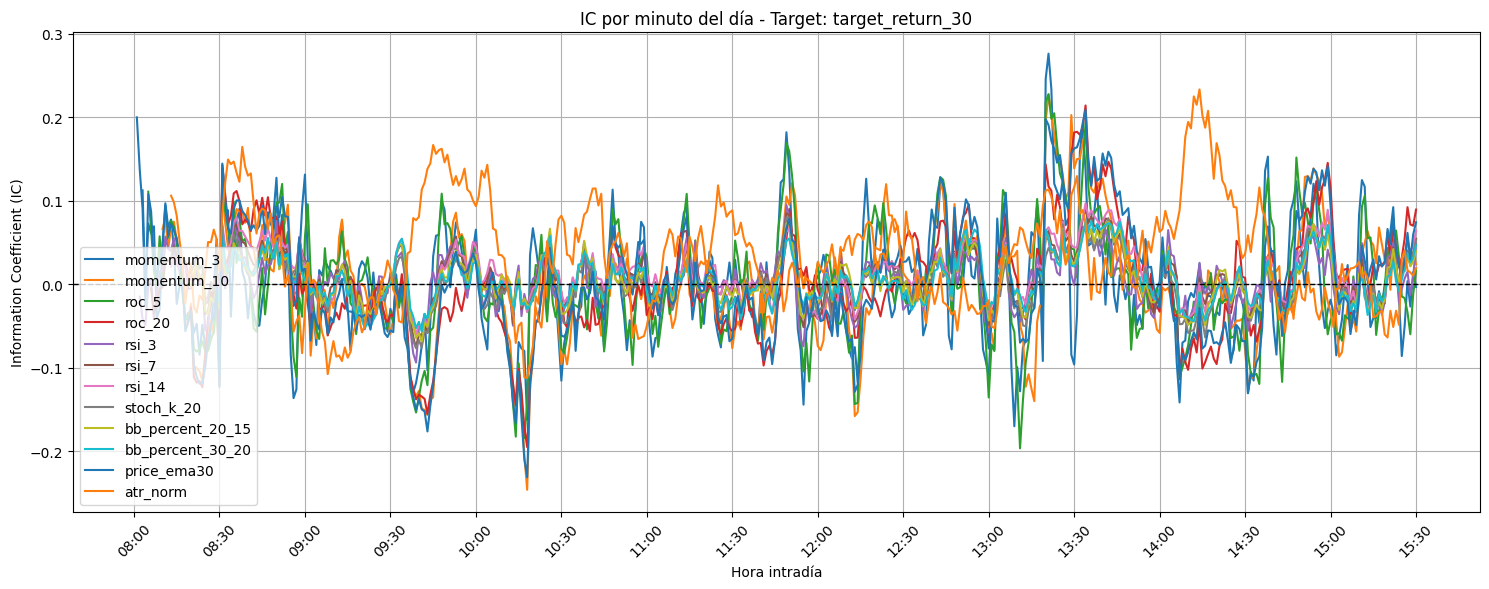

In [ ]:
# 1. Calcular el IC por minuto para los mejores factores
ic_por_minuto = plot_ic_tecnicos_por_minuto(mnq_intraday, mejores_indicadores_tecnicos, target='target_return_30')

Observemos el comportamiento de los IC en ventanas de 60 min, y busquemos cual es la mejor y la peor hora para tomar en cuenta estos indicadores.

In [ ]:
ic_minute_df = pd.DataFrame(ic_por_minuto)
resumen_60 = analizar_ic_ventanas_min(ic_minute_df,  ventana=120)

In [ ]:
resumen_60

,Alpha Factor,Promedio peor bloque 60min,Rango peor bloque 60min,Promedio mejor bloque 60min,Rango mejor bloque 60min
0,atr_norm,-0.006074,09:41 - 10:40,0.085377,14:39 - 15:38
1,price_ema30,-0.055730,10:22 - 11:21,0.075424,13:49 - 14:48
2,roc_20,-0.054126,10:22 - 11:21,0.068771,13:50 - 14:49
3,momentum_10,-0.044588,10:35 - 11:34,0.060805,13:42 - 14:41
4,roc_5,-0.032817,10:34 - 11:33,0.043708,13:40 - 14:39
5,rsi_14,-0.004609,09:58 - 10:57,0.039964,13:50 - 14:49
6,bb_percent_30_20,-0.007846,10:16 - 11:15,0.033326,13:49 - 14:48
7,momentum_3,-0.024163,10:18 - 11:17,0.032862,13:39 - 14:38
8,rsi_7,-0.007381,14:47 - 15:46,0.030689,13:47 - 14:46
9,bb_percent_20_15,-0.010962,14:49 - 15:48,0.027426,13:49 - 14:48


Con base en el análisis sobre el IC promedio por bloques de 60 minutos, puedo extraer varias conclusiones relevantes para la operativa intradía y la selección temporal de tus indicadores técnicos:

**1. El mejor momento para operar con indicadores técnicos es entre las 13:39 y 14:49**
- La gran mayoría de los factores muestran su mejor rendimiento predictivo en este rango horario: `price_ema30`, `roc_20`, `rsi_14`, `bb_percent_30_20`, `bb_percent_20_15`, `stoch_k_20`, `momentum_3`, `rsi_7`, `rsi_3`...
- Esto sugiere que hay más consistencia y direccionalidad en el mercado durante este tramo, probablemente debido a una menor presencia de “ruido” y una mayor participación institucional pre-cierre.

**2. El peor rendimiento se concentra entre las 09:41 y 11:34**
- Indicadores como `atr_norm`, `price_ema30`, `roc_20`, `momentum_10`, `roc_5`, `rsi_14`, `bb_percent_30_20` tienen sus bloques más débiles en esta franja.
- Esto podría estar relacionado con la alta volatilidad y comportamiento errático de la apertura, que puede confundir a muchos factores técnicos.

**3. Algunos indicadores son más estables y consistentes**
- `atr_norm` y `rsi_14` tienen promedios negativos muy bajos en sus peores bloques, lo que indica que incluso en sus peores momentos, no generan señales fuertemente equivocadas.
- Esto los convierte en candidatos robustos para modelos que busquen consistencia a lo largo del día.

**4. Otros factores son altamente sensibles al contexto horario**
- `price_ema30` y `roc_20` tienen diferencias marcadas entre su peor y mejor bloque (más de 0.13 en IC), mostrando que su utilidad depende mucho del horario en que se usan.
- Podrías considerar usar estos factores solo en rangos temporales favorables o ponderarlos según la hora del día en tu modelo predictivo.

**Recomendaciones prácticas**

- Para entrenamiento de modelos o ejecución de señales: prioriza el uso de datos entre las 13:39 y 14:49.
- Si tu modelo es sensible a errores, evita tomar decisiones automáticas entre las 10:00 y 11:30, o usa estrategias conservadoras en ese rango.
- Considera agregar la hora del día como variable explicativa, o entrenar modelos separados por bloques horarios (por ejemplo: apertura, mediodía, pre-cierre).




In [ ]:
mnq_intraday

,date,open,high,low,close,volume,target_return_30,momentum_3,momentum_10,roc_5,roc_20,rsi_3,rsi_7,rsi_14,stoch_k_20,bb_percent_20_15,bb_percent_30_20,price_ema30,atr_norm
datetime,,,,,,,,,,,,,,,,,,,
2019-12-23 08:00:00-05:00,2019-12-23,8734.00,8734.25,8733.75,8733.75,31,0.000372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000
2019-12-23 08:01:00-05:00,2019-12-23,8734.00,8734.25,8733.75,8734.00,16,0.000286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.383501e-05,0.000000
2019-12-23 08:02:00-05:00,2019-12-23,8734.00,8734.00,8733.25,8733.25,23,0.000315,NaN,NaN,NaN,NaN,18.181818,NaN,NaN,NaN,NaN,NaN,-4.640816e-05,0.000000
2019-12-23 08:03:00-05:00,2019-12-23,8734.25,8734.50,8734.00,8734.00,23,0.000315,0.000029,NaN,NaN,NaN,63.265306,NaN,NaN,NaN,NaN,NaN,2.859176e-05,0.000000
2019-12-23 08:04:00-05:00,2019-12-23,8734.00,8734.00,8733.50,8733.75,12,0.000458,-0.000029,NaN,NaN,NaN,49.600000,NaN,NaN,NaN,NaN,NaN,-2.535945e-08,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-13 15:56:00-04:00,2025-06-13,21624.50,21635.00,21613.50,21617.50,3251,NaN,-0.000231,0.000278,-0.094741,-0.073959,33.780079,39.066557,42.096236,22.413793,0.128027,0.206181,-8.844700e-04,0.000871
2025-06-13 15:57:00-04:00,2025-06-13,21616.50,21635.25,21615.75,21623.75,2201,NaN,0.000382,0.000243,-0.047379,-0.156988,52.504050,45.637235,45.107585,31.034483,0.266734,0.306572,-5.572032e-04,0.000873
2025-06-13 15:58:00-04:00,2025-06-13,21623.25,21632.75,21616.50,21621.75,1859,NaN,-0.000127,0.000104,-0.003469,-0.219205,46.229664,43.871077,44.313396,28.373702,0.255214,0.280376,-6.077556e-04,0.000864
